## Model Selection

First we are going to compute SHAP values for the models we found in the 4_modelling notebook. We are actually going to use the order 2 models for both the linear and hybrid case, even though in the hourly case technically the order 0 models performed slightly better than the order 2 ones, it would be interesting to see whether or not the models are using trend and trend_squared as important features. We are going to rank features by their mean absolute SHAP value and take the top 30 to form a reduced feature set. We then repeat the forecasting of 4_modelling to compare how these reduced feature set models perform compared to their full feature set counterparts.

Then we are going to perform hyperparameter tuning with Optuna for the xgboost models in both the standalone form (base_non_linear) as well as the xgboost model that forms part of the hybrid model.


In [1]:
import optuna
from jfk_taxis import load_design, load_config, load_models, load_lags, create_val_data, objective_optuna, save_hyperparams, load_hyperparams, save_obj, load_obj, split_params, test_hyperparams, load_ts_data, split_test_train_sets, load_process_lags, compute_shap_values, shap_plots, extract_top_x_features_dict, create_train_save_models, run_forecasts, save_extracted_features_to_config, make_offsets, save_config
from sklearn.linear_model import LinearRegression
import numpy as np
from xgboost import XGBRegressor
from functools import partial

In [2]:
# Load config and project root
config, PROJECT_ROOT = load_config()


In [3]:
# First load the significant lags
daily_lags, used_hourly_lags = load_process_lags()

In [4]:
# Load ts data
ts_daily, ts_hourly = load_ts_data()

In [5]:
# Create test train sets as defined in config.yml
ts_daily_train, ts_daily_test, ts_hourly_train, ts_hourly_test = split_test_train_sets(ts_daily, ts_hourly)

## SHAP values

We now seek to explore the shap values of the models. We are going to use order 2 for the model order in both the linear and hybrid case for the same reasons as stated above. It will turn out that actually trend and trend_squared are not important features by mean absoulute SHAP value so we can simply refit all the models onto this reduced feature set. We compute the SHAP values and rank the features by mean absolute SHAP value taking the top 30. These are then going to form our reduced feature set which is over a 10x reduction in features. 

Note due to the size of the design matricies we take a random sample of the rows when computing the SHAP values. For both the daily and hourly models we have set this random sample to be at most 10,000. For the daily models that will be the entire design matrix. The full hourly series is approx 127,000 rows so we are saving roughly 10x on memory usage, this allows us to run the computations in containers with less than 8GB of RAM whilst getting similar results in terms of identifiying feature importance when compared to computing on the entire design matrix.

In [6]:
# First we assemble the design and model signatures from config.yml
DAILY_LINEAR_SIG = config["model_sigs"]["daily_linear"]
DAILY_HYBRID_SIG = config["model_sigs"]["daily_hybrid"]
HOURLY_LINEAR_SIG = config["model_sigs"]["hourly_linear"]
HOURLY_HYBRID_SIG = config["model_sigs"]["hourly_hybrid"]

# Now we get the model prefixes from config.yml
DAILY_LINEAR_PREFIX = config["model_naming"]["linear_model_prefix"] + "2"
DAILY_HYBRID_PREFIX = config["model_naming"]["hybrid_model_prefix"] + "2"
HOURLY_LINEAR_PREFIX = config["model_naming"]["linear_model_prefix"] + "2"
HOURLY_HYBRID_PREFIX = config["model_naming"]["hybrid_model_prefix"] + "2"
DEFAULT_NON_LINEAR_PREFIX = config["model_naming"]["default_non_linear"]

# Daily prefix
DAILY_PREFIX = config["shap"]["daily_prefix"]

# Hourly prefix 
HOURLY_PREFIX = config["shap"]["hourly_prefix"]

# Titles for plots and to key values for dicts
DAILY_LINEAR_NAME = f"{DAILY_PREFIX}_{DAILY_LINEAR_PREFIX}"
DAILY_HYBRID_NAME = f"{DAILY_PREFIX}_{DAILY_HYBRID_PREFIX}"
DAILY_NON_LINEAR_NAME = f"{DAILY_PREFIX}_{DEFAULT_NON_LINEAR_PREFIX}"
HOURLY_LINEAR_NAME = f"{HOURLY_PREFIX}_{HOURLY_LINEAR_PREFIX}"
HOURLY_HYBRID_NAME = f"{HOURLY_PREFIX}_{HOURLY_HYBRID_PREFIX}"
HOURLY_NON_LINEAR_NAME = f"{HOURLY_PREFIX}_{DEFAULT_NON_LINEAR_PREFIX}"

# Sampel size, due to the large size of the data sets, particularly the hourly time series, we take a sample of the design matrix to compute the SHAP values on
daily_sample_size = config["shap"]["daily_sample_size"] # 10,000 this is actually more rows than in the full daily time series so we essentially do all of it
hourly_sample_size = config["shap"]["hourly_sample_size"] # 10,000

# Dictionary to store the shap values (it will contain tuples of shap values and design matricies)
shap_values_dict = {}


In [7]:
# Compute the SHAP values for daily non linear
shap_values, X = compute_shap_values(DAILY_LINEAR_SIG, DAILY_LINEAR_SIG, DEFAULT_NON_LINEAR_PREFIX, linear= False, hybrid= False, sample_size = daily_sample_size)

 99%|===================| 4349/4377 [01:04<00:00]        

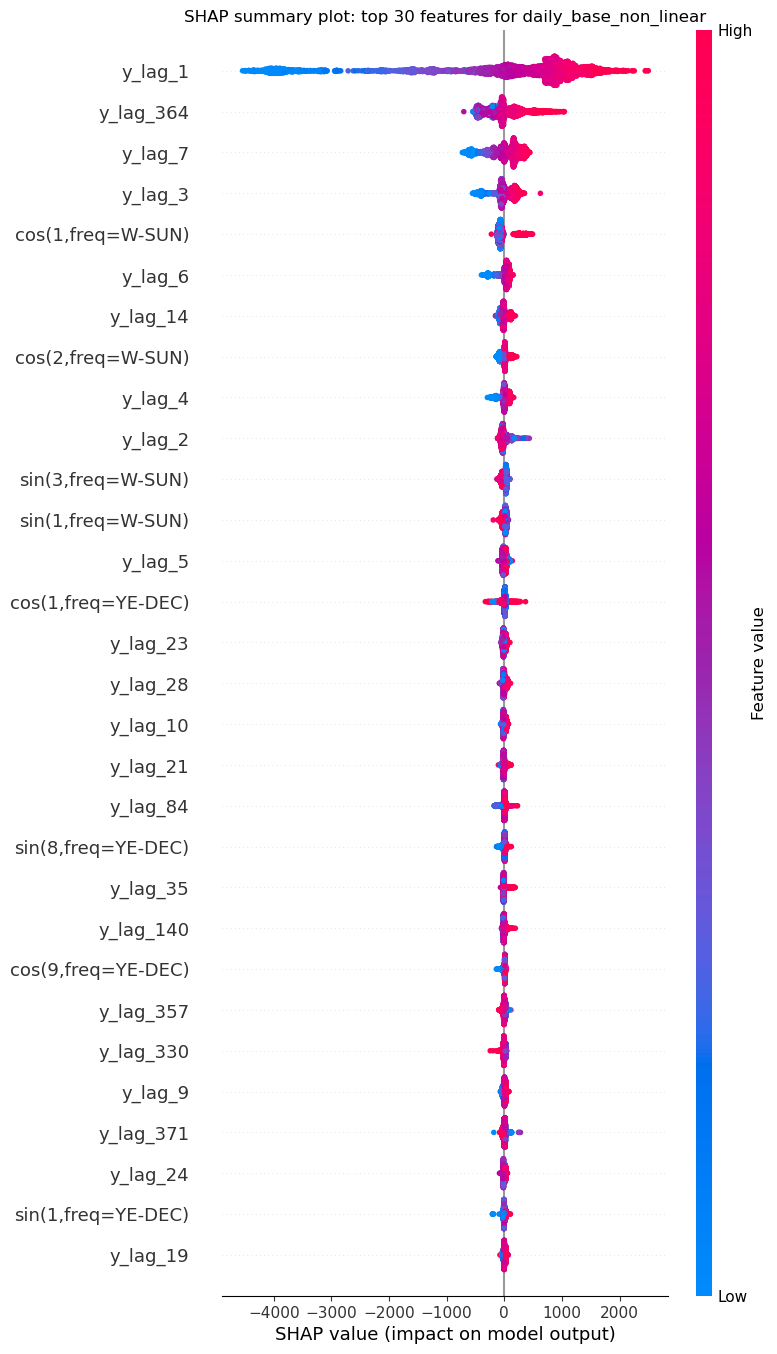

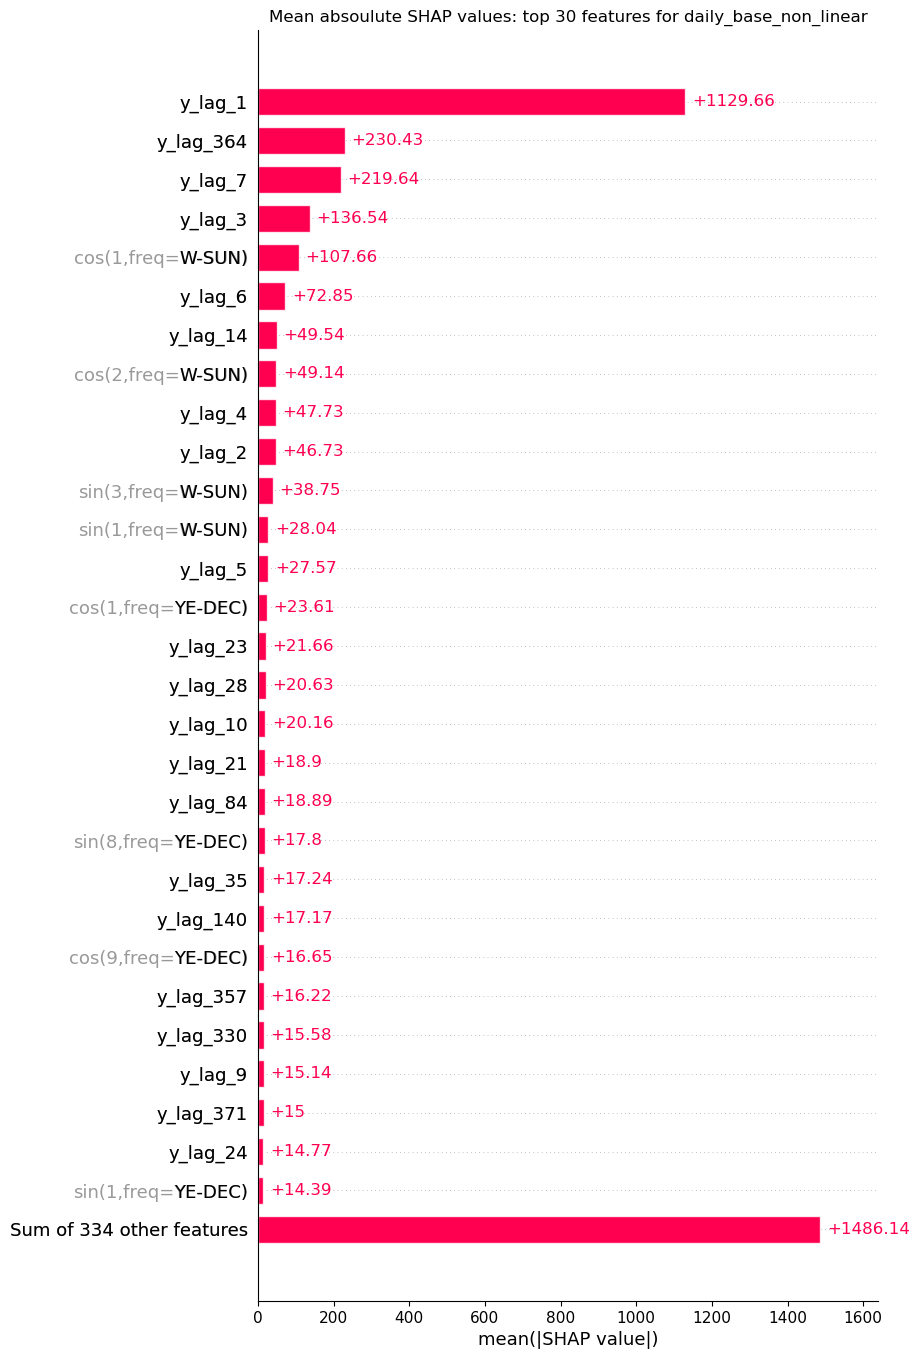

In [8]:
# Create summary plot and bar plot by mean absolute value
shap_plots(shap_values, X, DAILY_NON_LINEAR_NAME)

In [9]:
# Store shap values and design matrix in dict
shap_values_dict[DAILY_NON_LINEAR_NAME] = (shap_values, X)

As you can see in the above SHAP summary plot, lag_1 has the widest spread with low feature values causing low impact on model output and vice versa. It is interesting that lag_1 is the most significant feature by SHAP value as during testing I tried several different naive baselines, like lag of 1, lag of 7 etc etc and lag of 1 was consitently the best which is supported here by our SHAP values. 

Interestingly you also see that lag_7 and lag_364 have reasonably wide spreads again lining up with our EDA that there was both weekly and yearly seasonality in the taxi data. Now this is an XGBoost model so it is interesting that it has picked up on the lags more rather than the fourier features when looking at seasonality. Although the model does still make use of the fourier features. 

It's worth looking at a daily linear model to see if it favours the fourier features over the lags.

In [10]:
# Compute SHAP values for daily linear_order2
shap_values, X = compute_shap_values(DAILY_LINEAR_SIG, DAILY_LINEAR_SIG, DAILY_LINEAR_PREFIX, linear= True, hybrid= False, sample_size = daily_sample_size)

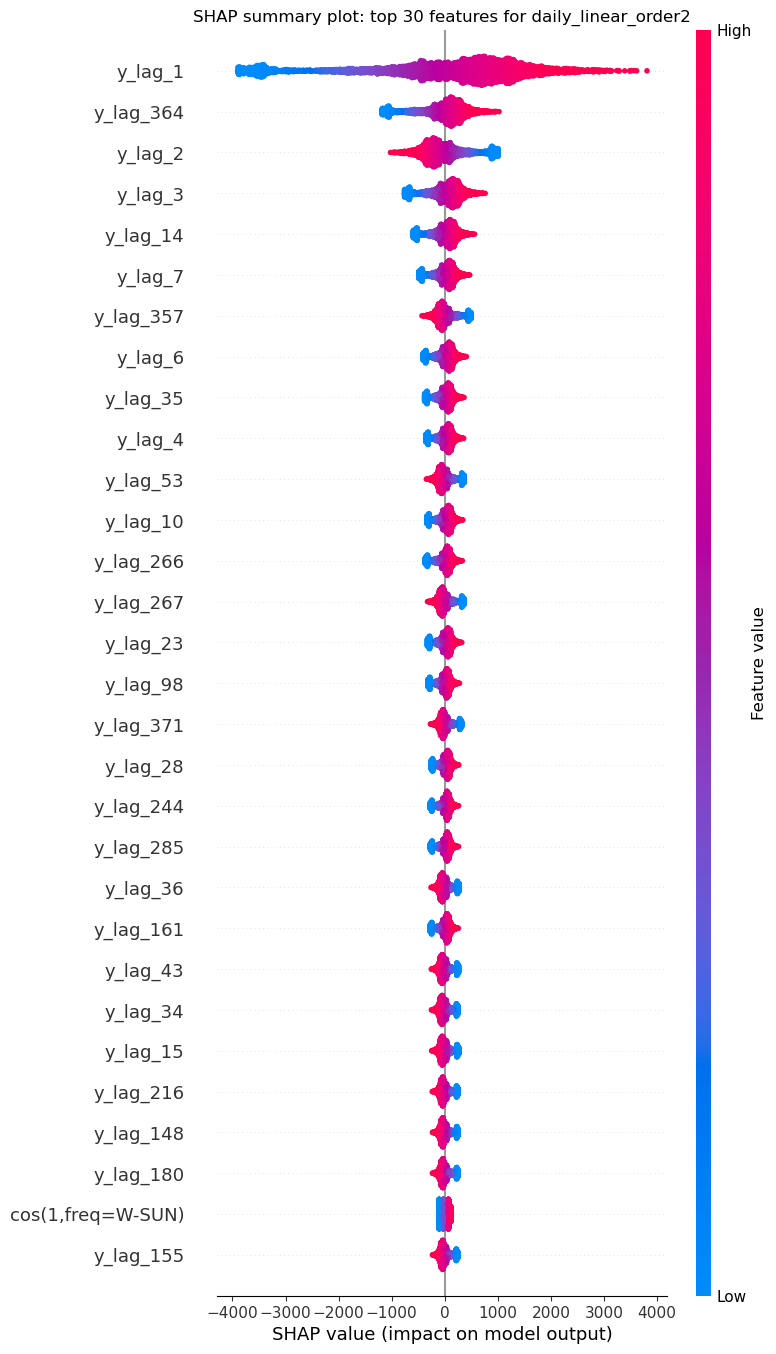

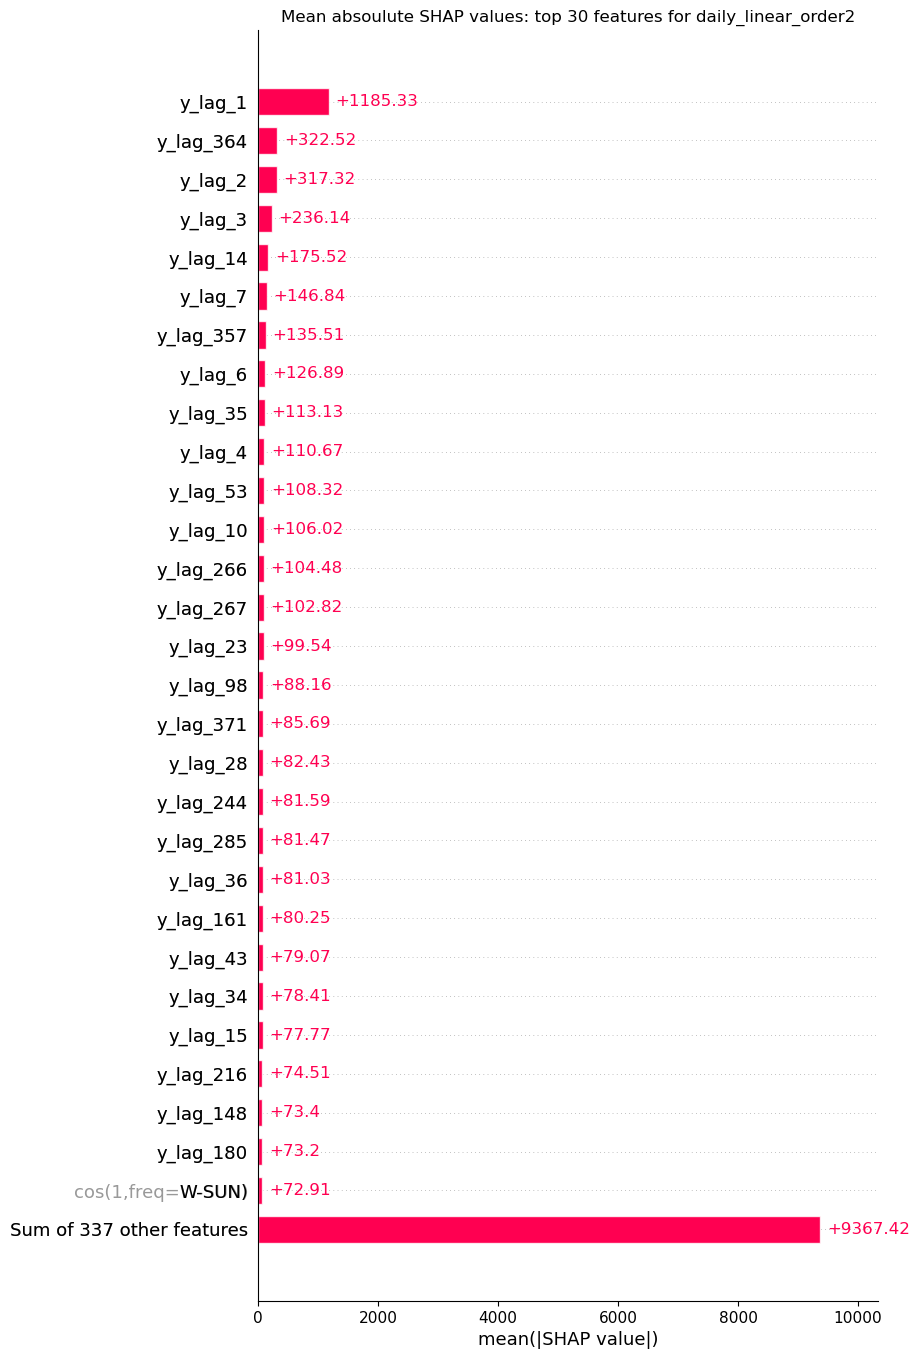

In [11]:
# Create summary plot and bar plot by mean absolute value
shap_plots(shap_values, X, DAILY_LINEAR_NAME)

In [12]:
# Store shap values and design matrix in dict
shap_values_dict[DAILY_LINEAR_NAME] = (shap_values, X)

The above is super interesting because it shows that our fourier features aren't at the top at all here. This goes against what I expected as I orignally thought that the linear regression would like the smooth fourier features that could allow it to capture things like annual seasonality. But it seems it has used the lags like lag_364 and lag_7 to capture the seasonality instead. 

This seems to be more of a memory property of the data, as in the value last year affects the value this year more than the yearly up and down of say slightly more taxis around the holidays (due to more flights). So lag features like lag 364 can better capture both the seasanolity of 1 year but also the year on year effects, like high values last year means high values this year is likely. 

There are a couple interesting things to note in terms of the shape on the summary plots. For example for lag 2 it seems high values 2 days ago cause a decrease in the model prediction and vice versa. But high values one day ago strongly suggest high values the next day. Lag 7 and lag 14 have high mean absolute shap values which is again our weekly seasonality in lag form. 

The other thing that is super intersting is the trend doesn't seem to appear in the top 30. This suggests it's not significant for the model. However this is slightly suspicious as from our inital modelling it seems that linear_order2 outperformed the other linear_order models in the daily case, which would suggest that the trend had some effect on the outcome particualarly long term. So it may be worth adding the trend back in particularly for long term forecasts.

Finally it would be interesting to have an inital look at the SHAP values for the XGBoost component of the hybrid models, just to see what they are picking up. We will do this for hybrid_order2.

In [13]:
# Compute SHAP values for daily hybrid_order2
shap_values, X = compute_shap_values(DAILY_HYBRID_SIG, DAILY_HYBRID_SIG, DAILY_HYBRID_PREFIX, linear= True, hybrid= True, sample_size = daily_sample_size)

 98%|===================| 4295/4377 [00:55<00:01]        

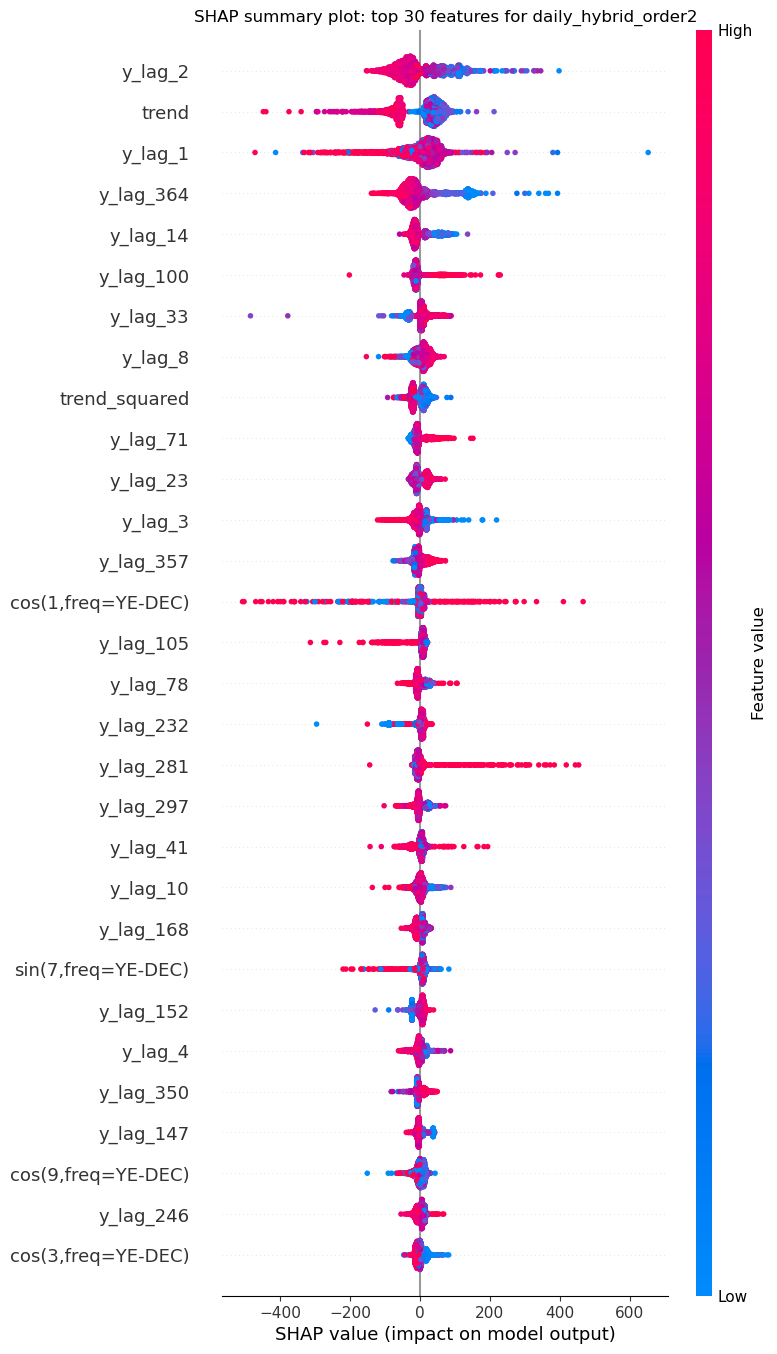

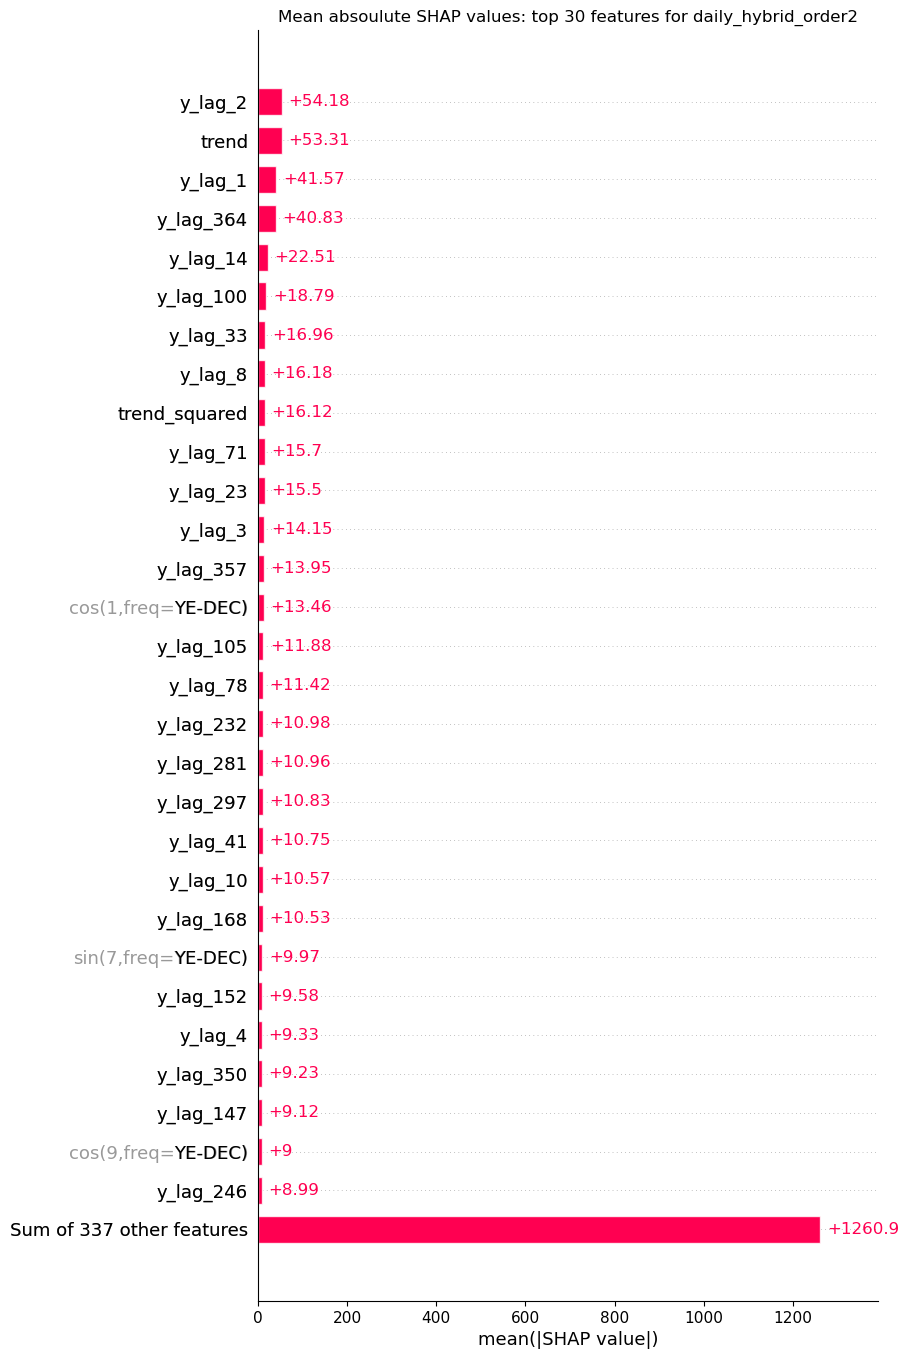

In [14]:
# Create summary plot and bar plot by mean absolute value
shap_plots(shap_values, X, DAILY_HYBRID_NAME)

In [15]:
# Store shap values and design matrix in dict
shap_values_dict[DAILY_HYBRID_NAME] = (shap_values, X)

The above is intersting. It would seem trend is one of the most important feature according to mean absolute SHAP value. There is actually a good plausible explanation for this. Notice that high values of trend cause a decrease in model predictions. We know from 1_EDA that over the years taxi pick ups at JFK have overal declined. Possibly the xgboost model is using trend to somehow capture this slow decline over time. y_lag_2 is interestingly the most important feature, and is also negatively coded so large values of y_lag_2 cause a decrease in model prediction. Again this is perhaps trying to caputre instances where large values of taxi pick ups are then followed by a decrease rather than increase.

It's also very clear that these effects are much smaller than that of the underlying model (hybrid_order2s linear component is the same as for linear_order2) with y_lag_2 only having mean absoulute SHAP value of 54.18 compared to the linear components 1185.33 for y_lag_1.

We now do the same for the hourly models.



In [16]:
# Compute the SHAP values for hourly non linear
shap_values, X = compute_shap_values(HOURLY_LINEAR_SIG, HOURLY_LINEAR_SIG, DEFAULT_NON_LINEAR_PREFIX, linear= False, hybrid= False, sample_size = hourly_sample_size)

Sampling 10000 rows from 105168 for SHAP computation


100%|===================| 9954/10000 [02:53<00:00]        

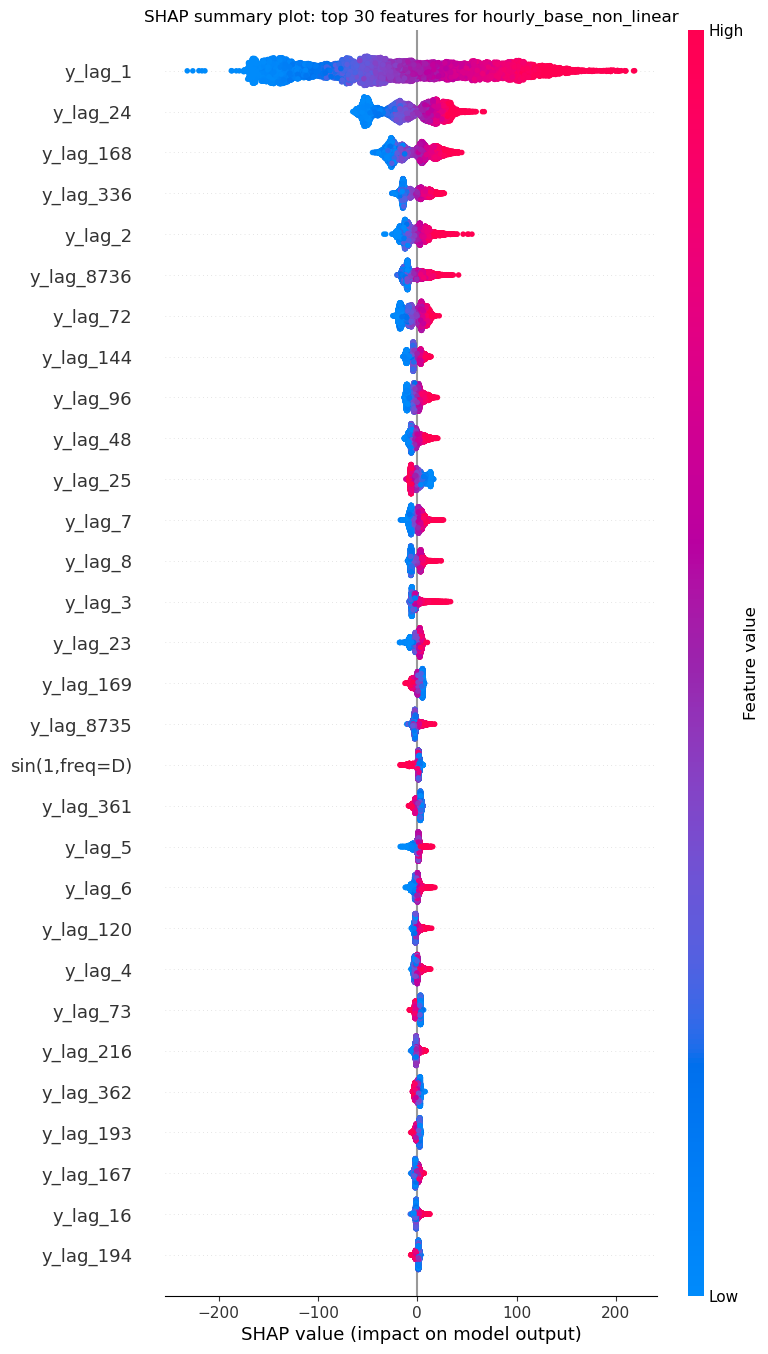

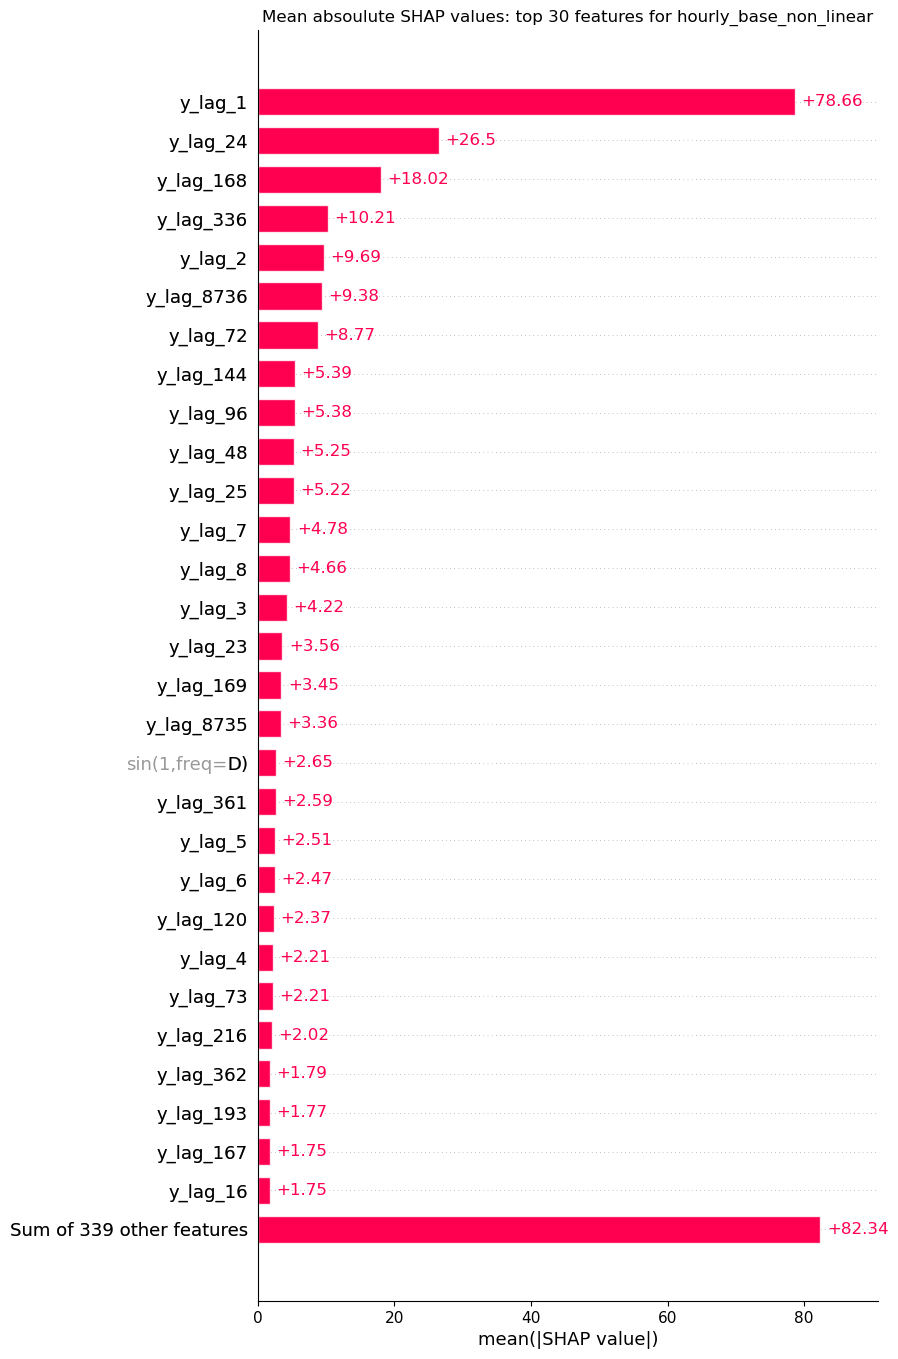

In [17]:
# Create summary plot and bar plot by mean absolute value
shap_plots(shap_values, X, HOURLY_NON_LINEAR_NAME)

In [18]:
# Store shap values and design matrix in dict
shap_values_dict[HOURLY_NON_LINEAR_NAME] = (shap_values, X)

In [19]:
# Compute the SHAP values for hourly linear_order2
shap_values, X = compute_shap_values(HOURLY_LINEAR_SIG, HOURLY_LINEAR_SIG, HOURLY_LINEAR_PREFIX, linear= True, hybrid= False, sample_size = hourly_sample_size)

Sampling 10000 rows from 105168 for SHAP computation


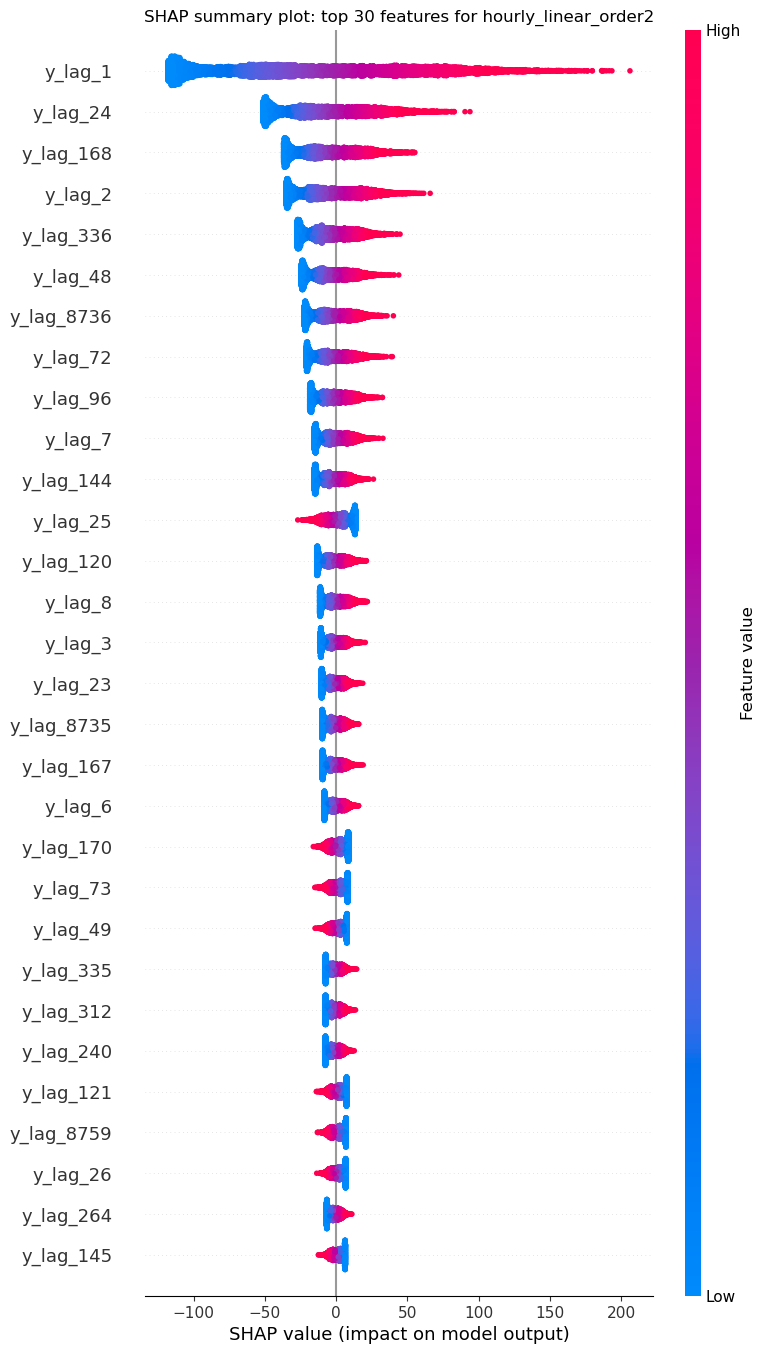

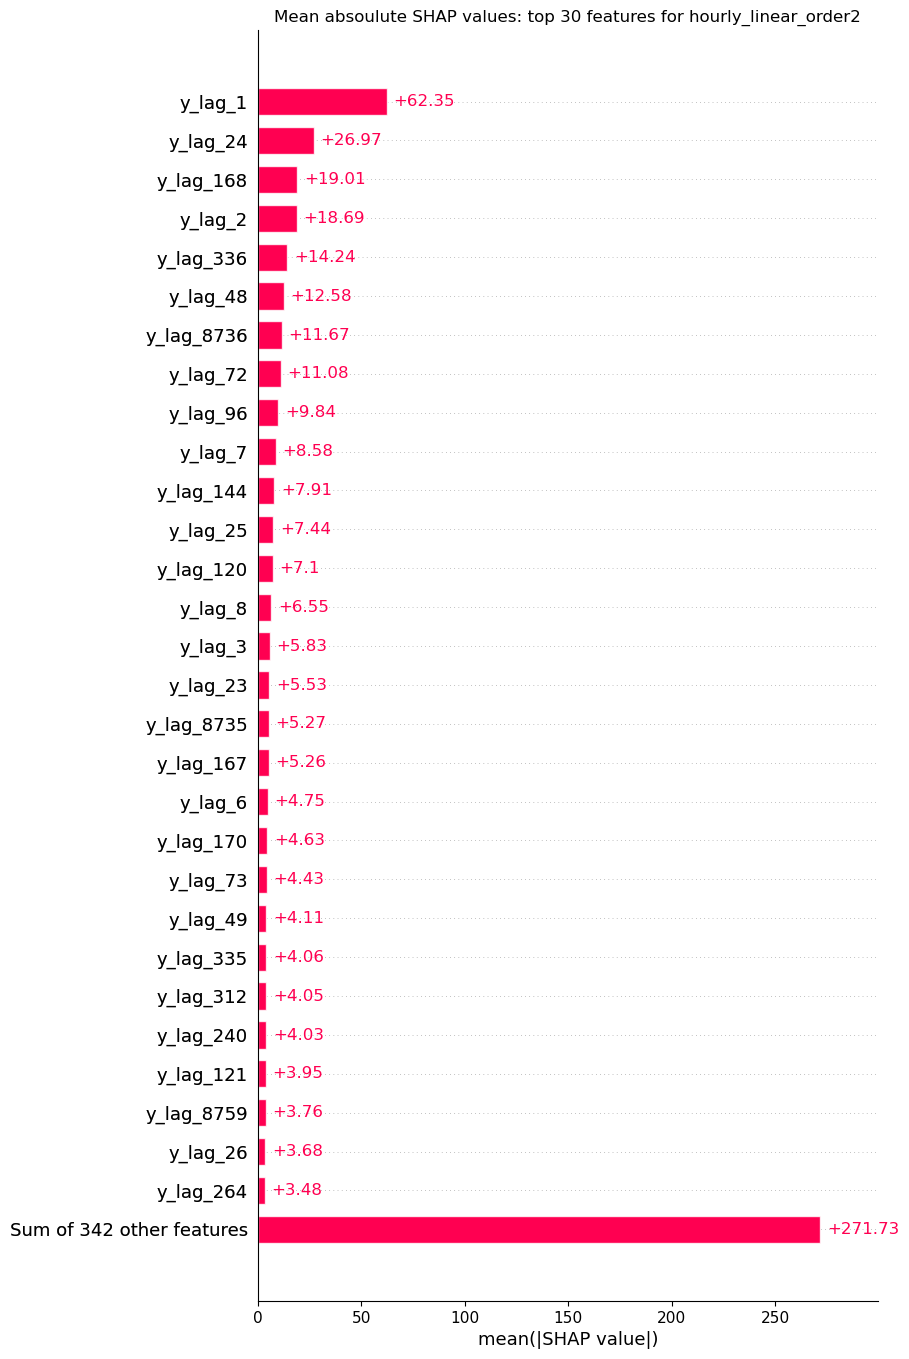

In [20]:
# Create summary plot and bar plot by mean absolute value
shap_plots(shap_values, X, HOURLY_LINEAR_NAME)

In [21]:
# Store shap values and design matrix in dict
shap_values_dict[HOURLY_LINEAR_NAME] = (shap_values, X)

In [22]:
# Compute the SHAP values for hourly hybrid_order2
shap_values, X = compute_shap_values(HOURLY_HYBRID_SIG, HOURLY_HYBRID_SIG, HOURLY_HYBRID_PREFIX, linear= True, hybrid= True, sample_size = hourly_sample_size)

Sampling 10000 rows from 105168 for SHAP computation


100%|===================| 9961/10000 [02:07<00:00]        

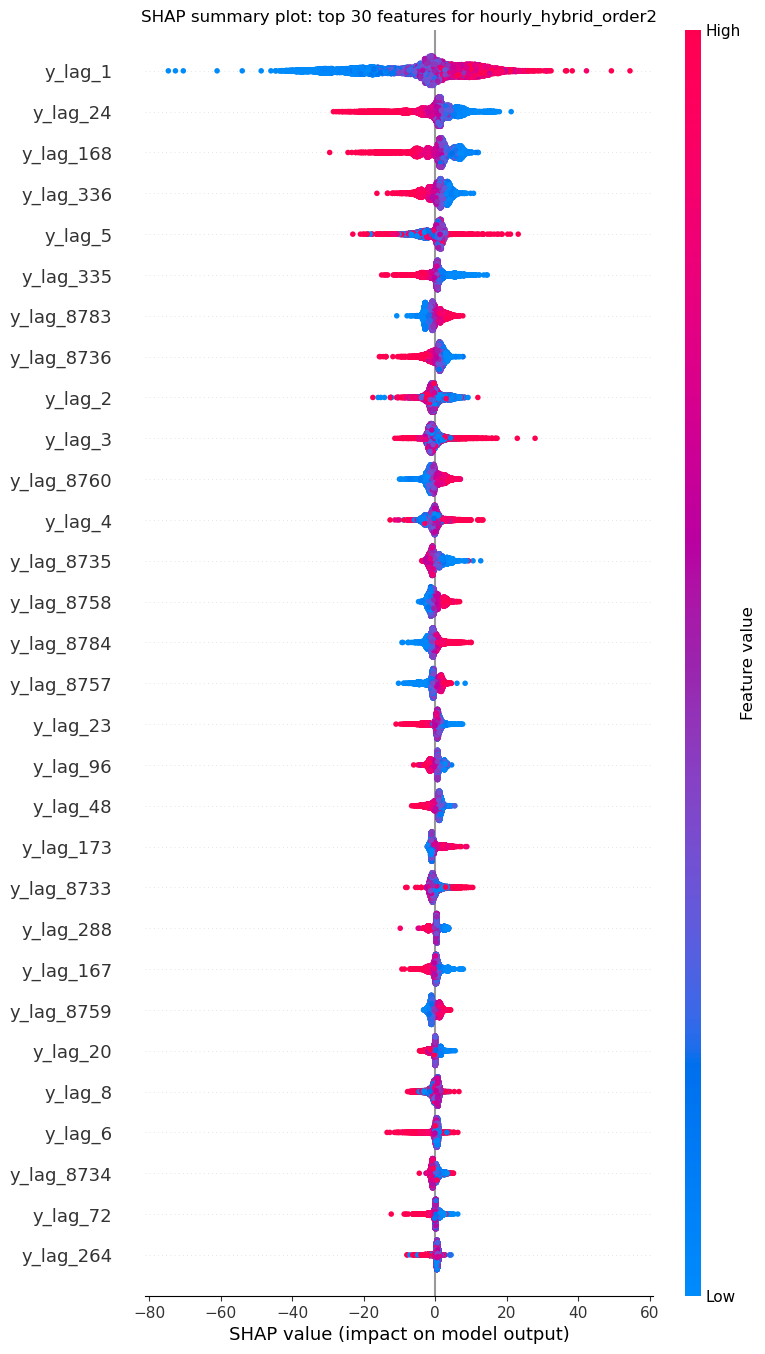

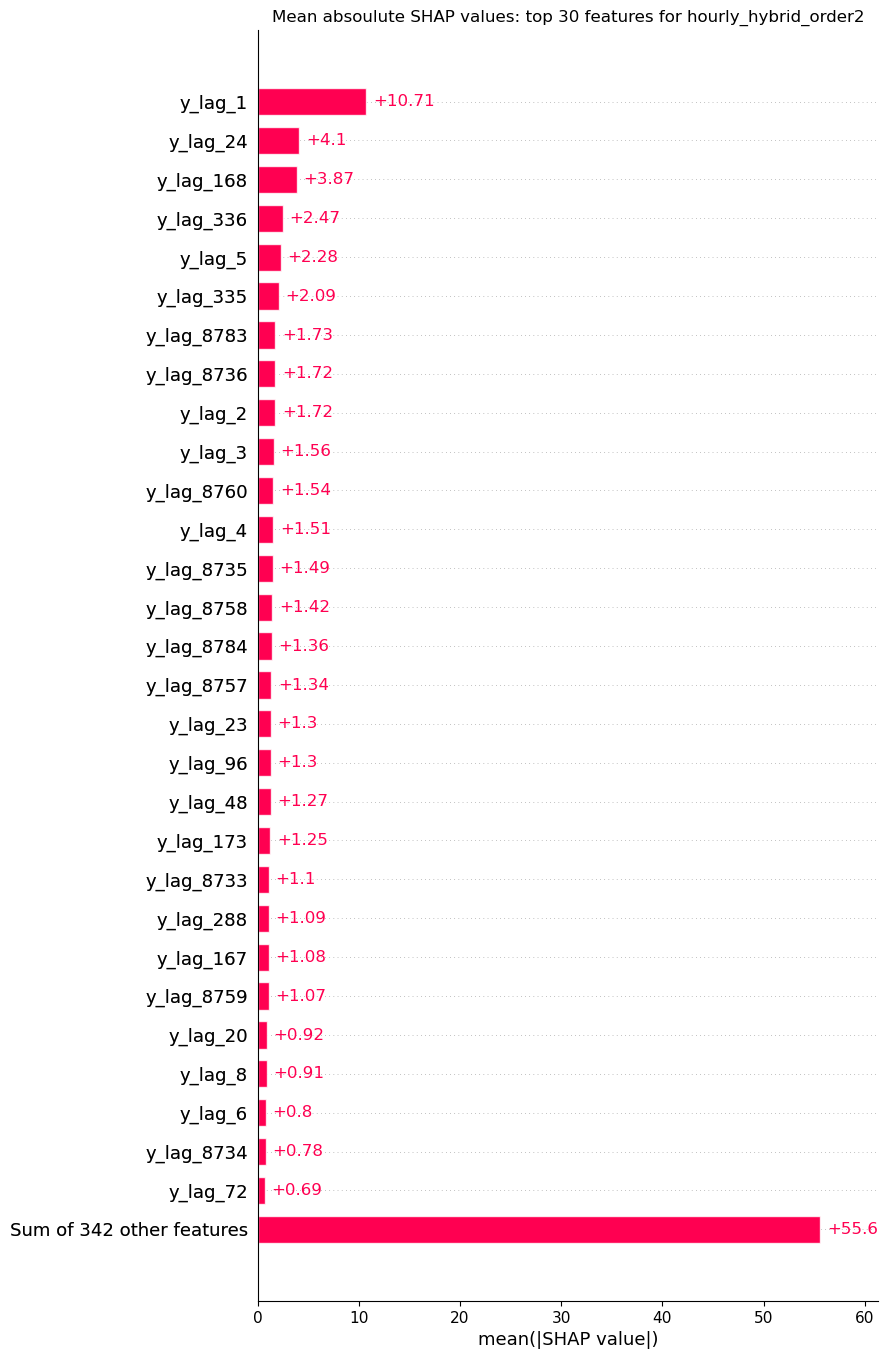

In [23]:
# Create summary plot and bar plot by mean absolute value
shap_plots(shap_values, X, HOURLY_HYBRID_NAME)

In [24]:
# Store shap values and design matrix in dict
shap_values_dict[HOURLY_HYBRID_NAME] = (shap_values, X)

In [25]:
# Save shap values dict
save_obj(shap_values_dict, config["saving"]["shap_values_file"])

What we immediately observe is we have the same pattern from the daily models. The daily and weekly seasonality (24 and 168 hours) both appear as lags rather than as their respective fourier features. We also see that once again lag 1 is the most important feature (by mean abs SHAP value) to both the linear and non linear models. 

We also see that the lag of 336 (168 * 2) which again linking back to 2_EDA_JFK it did appear that we had what looked like 2 weekly seasonality although we chose not to model it with fourier features. 

We further see that lag 8736 is significant in all three models, this is our yearly seasonality in the data. Although not flagged in the EDA (potentially because we tried 8760 for exactly one year, although this does show up in the hybrid but with less importance than 8736). If you read config.yml you can see we included some additional significant lags around 8760 and 4380 to try and capture any potential half or annual seasonlaity with the lags. We observe at least in the inital top 20 we can't see any half annual seasonality. But can see the annual lags.

What we would now like to do is select the top 30 features by mean absoulute SHAP value and retrain the models, to see if they caputre most of the signal. 

For the fourier features if we have at least one component (say just cos(2,freq=W-SUN)) then we will pass the entire weekly fourier feature, this is because there are likely interactions especially with say the sin(2,freq=W-SUN) feature and so removing them could mean this feature doesn't work the same way.



In [26]:
# Load shap values dict
shap_values_dict = load_obj(config["saving"]["shap_values_file"])

In [27]:
# Constant for number of top features to extract
TOP_X = config["shap"]["num_features_to_extract"]

In [28]:
# We extract the top X features for each model and in a new dict with the same keys as shap_values_dict but the values are now (list of lags, list of fourier features and list of trends)
top_x_features_dict = extract_top_x_features_dict(shap_values_dict, x = TOP_X)

In [29]:
# Save these values to the config
config = save_extracted_features_to_config(top_x_features_dict, config)

We will now re train these reduced feature models and compare them to the full feature ones to see whether the reduced models are still capturing a majority of the signal. If we can use a reduced feature set this both makes the models more easily explainable but will also significantly speed up our Bayesian hyperparamter tuning.

We are going to use the same setup as in the modelling.ipynb notebook.

In [30]:
# We are first going to do the daily non linear models

# Steps for the forecast (read config.yml to see and change the steps for the forecast)
steps = config["modelling"]["daily_steps"]

# Offset list
offset_list = config["modelling"]["daily_offset"]

# List of offsets to show the forecasts for
offset_to_show = config["modelling"]["daily_offsets_to_show"]

# Fourier features from extracted features
fourier_features = config["shap"][DAILY_NON_LINEAR_NAME]["extracted_fourier_features"]

# List of trend orders for our linear models, as we aren't using any linear models just set empty 
order_list = []

# Hybrid, the hybrid model we will be using
hybrid = None

# Time step of the series
time_step = "D"

# Time series to use for training
ts_train = ts_daily_train

# Time series to use for testing
ts_test = ts_daily_test

# Lags for training from the extracted features
lags = config["shap"][DAILY_NON_LINEAR_NAME]["extracted_lags"]

# Old lags list (this needs to be appened to the old models for when we forecast)
old_lags = daily_lags

# Linear name list (list of names for the linear models)
names_linear = []

# Non linear name list 
names_non_linear = [config["model_naming"]["reduced_daily_non_linear_model_prefix"]]

# Signature for the file names (this will be how we keep track of which files belong to which models when it comes to hyperparamter tuning)
sig = config["model_sigs"]["daily_non_linear_reduced"]

# Naive baseline (bool to determine whether or not to inlcude a naive baseline in the plots, the naive baseline will just predict time step value t as time step value t-1)
naive = True







In [31]:
# Create train and save the models
create_train_save_models(names_linear, names_non_linear, hybrid, sig, order_list, lags, fourier_features, time_step, ts_train)

In [32]:
# Load the models (and the deterministic processes)
linear_models_loaded, non_linear_models_loaded = load_models(sig)

# Load the previous non linear model
old_linear_models_loaded, old_non_linear_models_loaded = load_models(config["model_sigs"]["daily_linear"])

# Add the older non_linear_model to the new one
non_linear_models_loaded = {**old_non_linear_models_loaded, **non_linear_models_loaded}

MAE: 321.99 for step = 7, model = base_non_linear
MAE: 390.54 for step = 7, model = reduced_daily_non_linear
MAE: 621.71 for step =  30, model = Naive



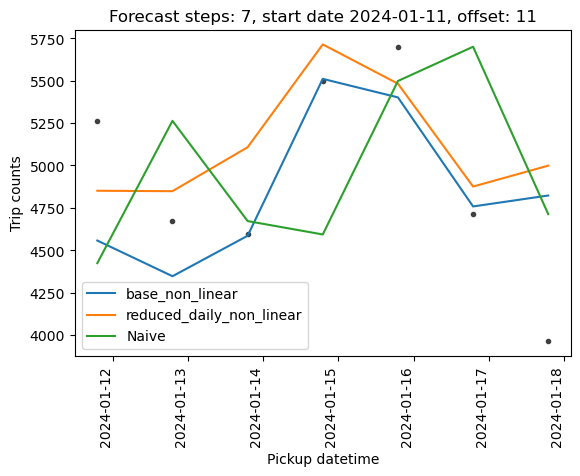

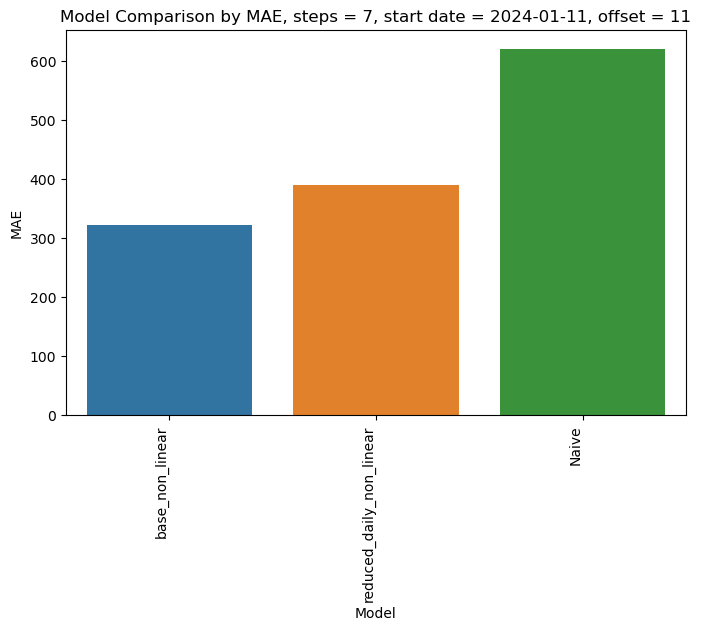

MAE: 844.57 for step = 30, model = base_non_linear
MAE: 730.41 for step = 30, model = reduced_daily_non_linear
MAE: 637.10 for step =  30, model = Naive



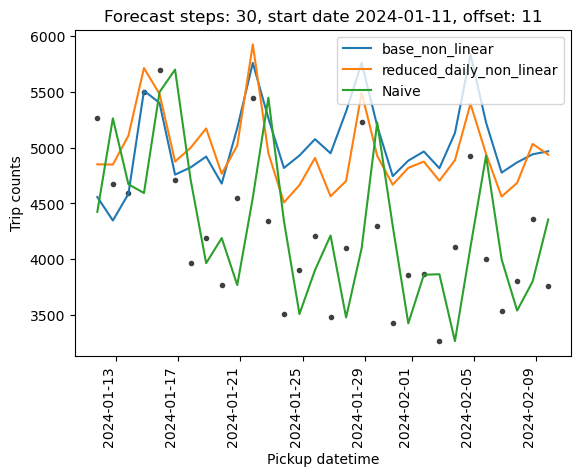

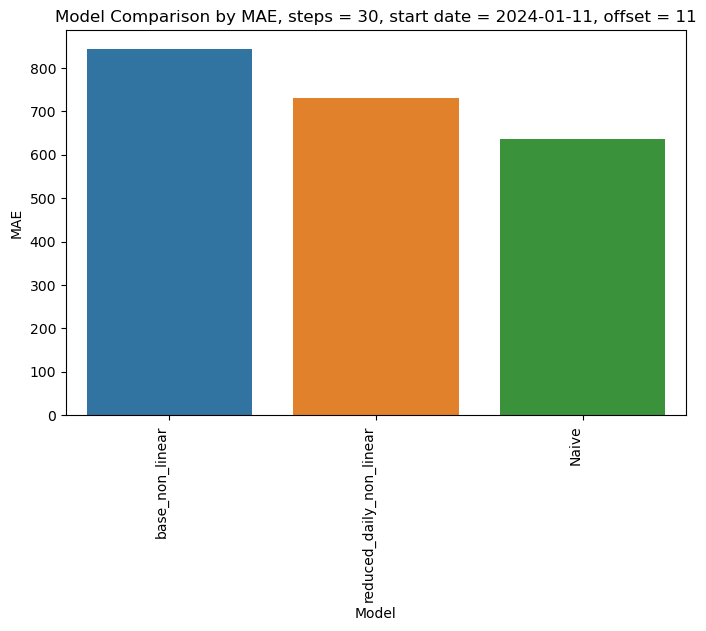

MAE: 805.95 for step = 60, model = base_non_linear
MAE: 731.02 for step = 60, model = reduced_daily_non_linear
MAE: 607.33 for step =  30, model = Naive



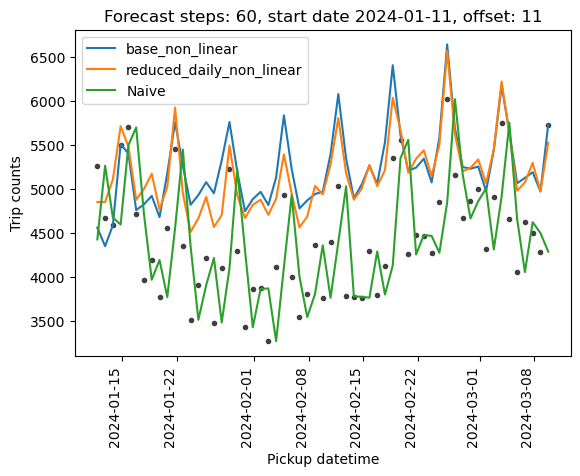

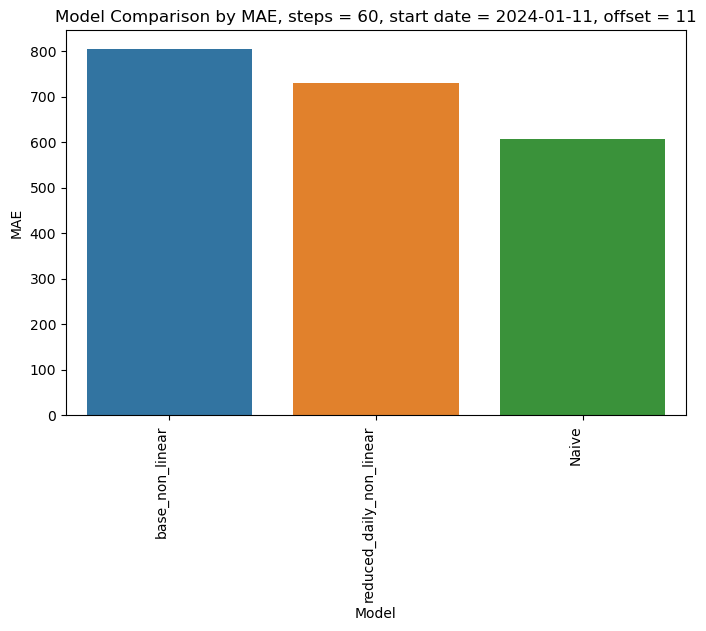


Average MAE scores for step 60:
base_non_linear, average MAE: 508.50
reduced_daily_non_linear, average MAE: 488.35
Naive, average MAE: 640.27

Average MAE scores for step 30:
base_non_linear, average MAE: 475.96
reduced_daily_non_linear, average MAE: 459.00
Naive, average MAE: 630.26

Average MAE scores for step 7:
base_non_linear, average MAE: 394.24
reduced_daily_non_linear, average MAE: 378.18
Naive, average MAE: 602.31


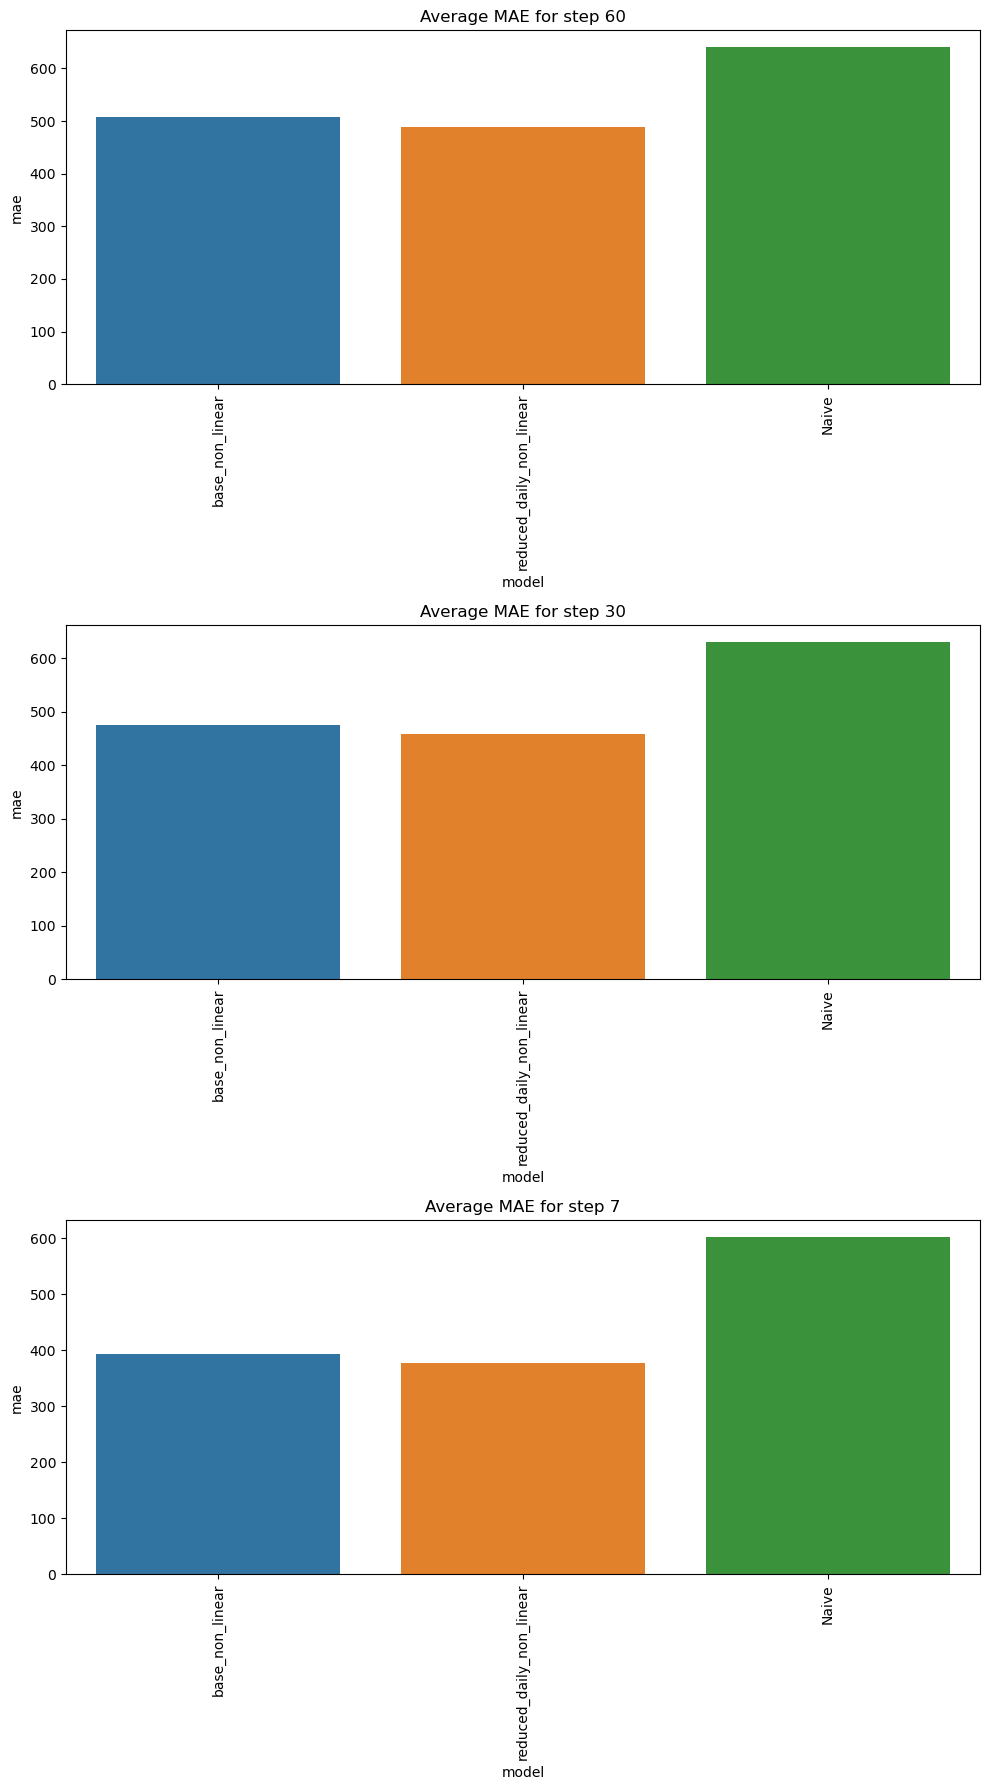

In [33]:
# Run forecasts
run_forecasts(steps, offset_list, offset_to_show, linear_models_loaded, non_linear_models_loaded, naive, time_step, ts_train, ts_test)

In [34]:
# daily linear models

# Steps for the forecast (read config.yml to see and change the steps for the forecast)
steps = config["modelling"]["daily_steps"]

# Offset list
offset_list = config["modelling"]["daily_offset"]

# List of offsets to show the forecasts for
offset_to_show = config["modelling"]["daily_offsets_to_show"]

# Fourier features from extracted features
fourier_features = config["shap"][DAILY_LINEAR_NAME]["extracted_fourier_features"]

# This is where I am going to slightly go against what was found using the top 30 features by mean abs shap value
# For both the daily and hourly time series the linear models didn't have any trend features in the top 30 (same for the linear part of the hybrid models as they are the same).
# This means that the SHAP values are suggesting that the trend features aren't very important for the linear models. However from the modelling
# notebook we do see a significant difference between the linear models based purely on difference in order, so we are going to test for order again but will include an order 0 model
# so just intercept to see whether that model is really superior to the others. (you can find the list in config.yml)
order_list = config["shap"]["daily_order_list"]

# Hybrid, the hybrid model we will be using
hybrid = None

# Time step of the series
time_step = "D"

# Time series to use for training
ts_train = ts_daily_train

# Time series to use for testing
ts_test = ts_daily_test

# Lags for training from the extracted features
lags = config["shap"][DAILY_LINEAR_NAME]["extracted_lags"]

# Old lags list (this needs to be appened to the old models for when we forecast)
old_lags = daily_lags

# Linear name list (list of names for the linear models)
names_linear = [f"{config['model_naming']['reduced_daily_linear_model_prefix']}{i}" for i in order_list]

# Non linear name list 
names_non_linear = []

# Signature for the file names (this will be how we keep track of which files belong to which models when it comes to hyperparamter tuning)
sig = config["model_sigs"]["daily_linear_reduced"]

# Naive baseline (bool to determine whether or not to inlcude a naive baseline in the plots, the naive baseline will just predict time step value t as time step value t-1)
naive = True




In [35]:
# Create train and save the models
create_train_save_models(names_linear, names_non_linear, hybrid, sig, order_list, lags, fourier_features, time_step, ts_train)

In [36]:
# Load the models (and the deterministic processes)
linear_models_loaded, non_linear_models_loaded = load_models(sig)

# Load the previous linear model
old_linear_models_loaded, old_non_linear_models_loaded = load_models(config["model_sigs"]["daily_linear"])

# Add the older non_linear_model to the new one
linear_models_loaded = {**linear_models_loaded, **old_linear_models_loaded}

MAE: 276.70 for step = 7, model = reduced_daily_linear_order0
MAE: 279.04 for step = 7, model = reduced_daily_linear_order1
MAE: 276.03 for step = 7, model = reduced_daily_linear_order2
MAE: 294.43 for step = 7, model = reduced_daily_linear_order3
MAE: 259.46 for step = 7, model = reduced_daily_linear_order4
MAE: 7434.61 for step = 7, model = reduced_daily_linear_order5
MAE: 361.28 for step = 7, model = linear_order0
MAE: 372.00 for step = 7, model = linear_order1
MAE: 365.42 for step = 7, model = linear_order2
MAE: 351.26 for step = 7, model = linear_order3
MAE: 378.59 for step = 7, model = linear_order4
MAE: 7434.61 for step = 7, model = linear_order5
MAE: 621.71 for step =  30, model = Naive



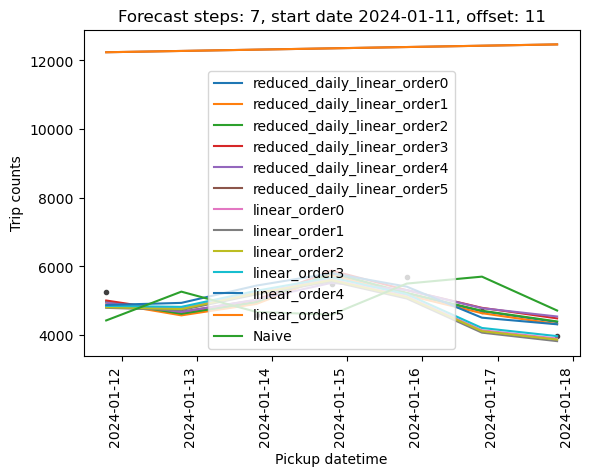

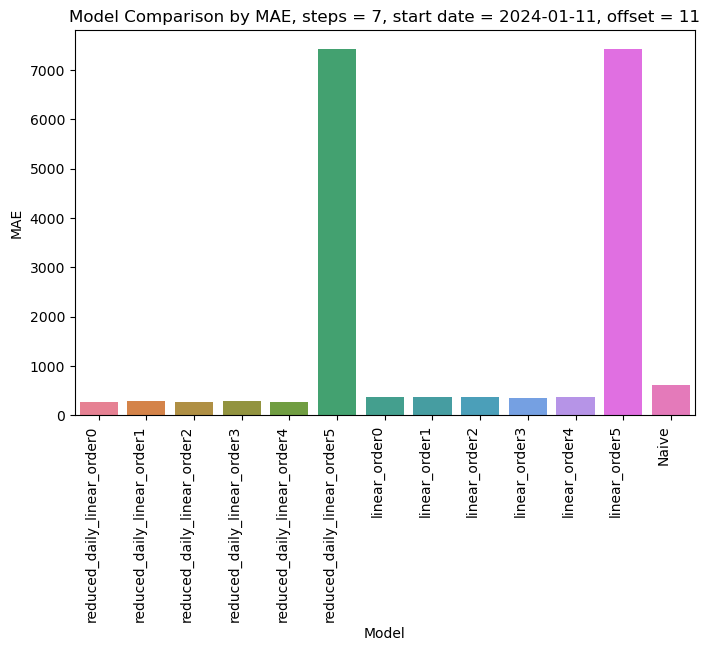

MAE: 520.64 for step = 30, model = reduced_daily_linear_order0
MAE: 433.41 for step = 30, model = reduced_daily_linear_order1
MAE: 549.40 for step = 30, model = reduced_daily_linear_order2
MAE: 695.35 for step = 30, model = reduced_daily_linear_order3
MAE: 628.41 for step = 30, model = reduced_daily_linear_order4
MAE: 8518.45 for step = 30, model = reduced_daily_linear_order5
MAE: 294.52 for step = 30, model = linear_order0
MAE: 323.09 for step = 30, model = linear_order1
MAE: 304.11 for step = 30, model = linear_order2
MAE: 305.40 for step = 30, model = linear_order3
MAE: 787.91 for step = 30, model = linear_order4
MAE: 8518.45 for step = 30, model = linear_order5
MAE: 637.10 for step =  30, model = Naive



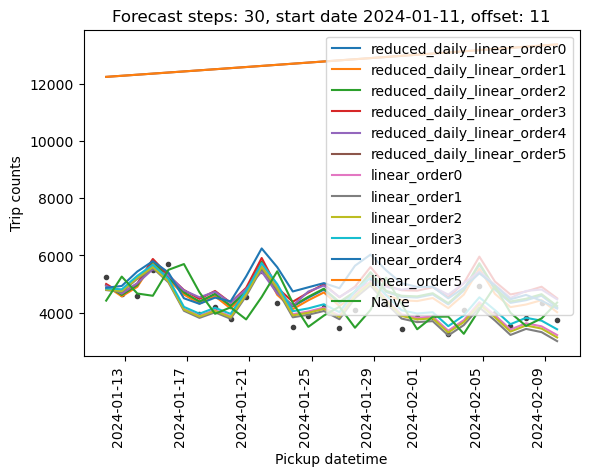

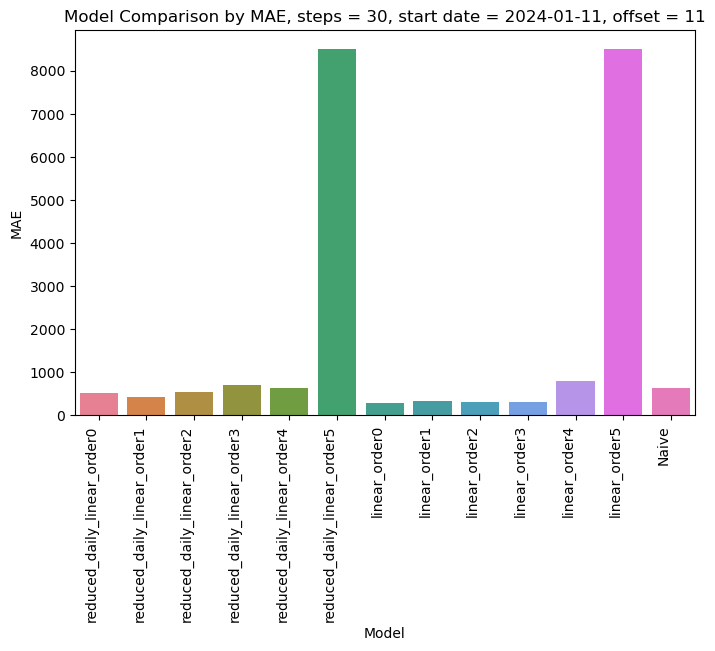

MAE: 452.77 for step = 60, model = reduced_daily_linear_order0
MAE: 421.52 for step = 60, model = reduced_daily_linear_order1
MAE: 473.23 for step = 60, model = reduced_daily_linear_order2
MAE: 664.16 for step = 60, model = reduced_daily_linear_order3
MAE: 610.29 for step = 60, model = reduced_daily_linear_order4
MAE: 8913.28 for step = 60, model = reduced_daily_linear_order5
MAE: 329.40 for step = 60, model = linear_order0
MAE: 362.53 for step = 60, model = linear_order1
MAE: 331.46 for step = 60, model = linear_order2
MAE: 398.95 for step = 60, model = linear_order3
MAE: 700.82 for step = 60, model = linear_order4
MAE: 8913.28 for step = 60, model = linear_order5
MAE: 607.33 for step =  30, model = Naive



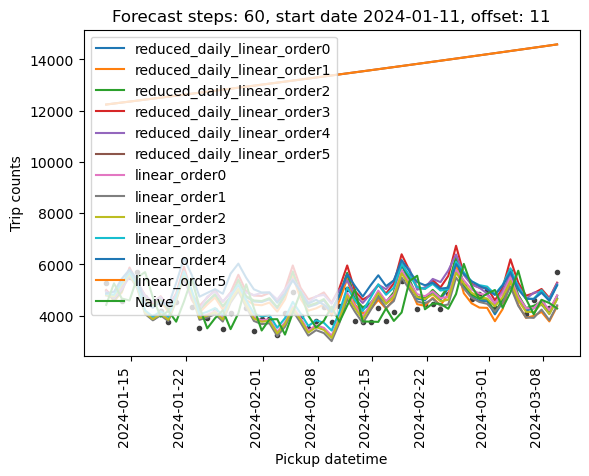

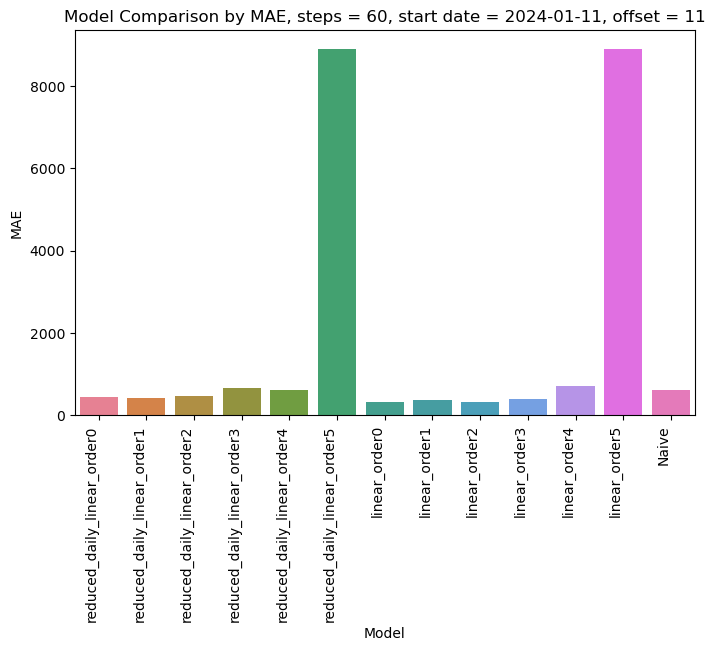


Average MAE scores for step 60:
reduced_daily_linear_order1, average MAE: 677.69
linear_order0, average MAE: 471.01
reduced_daily_linear_order0, average MAE: 610.29
reduced_daily_linear_order3, average MAE: 667.65
reduced_daily_linear_order4, average MAE: 638.46
reduced_daily_linear_order5, average MAE: 21146.02
linear_order3, average MAE: 649.23
reduced_daily_linear_order2, average MAE: 585.67
linear_order1, average MAE: 508.87
linear_order4, average MAE: 689.39
linear_order2, average MAE: 470.28
linear_order5, average MAE: 21146.02
Naive, average MAE: 640.27

Average MAE scores for step 30:
reduced_daily_linear_order1, average MAE: 534.90
linear_order0, average MAE: 418.62
reduced_daily_linear_order0, average MAE: 507.77
reduced_daily_linear_order3, average MAE: 511.27
reduced_daily_linear_order4, average MAE: 514.58
reduced_daily_linear_order5, average MAE: 20245.98
linear_order3, average MAE: 507.44
reduced_daily_linear_order2, average MAE: 497.51
linear_order1, average MAE: 420.8

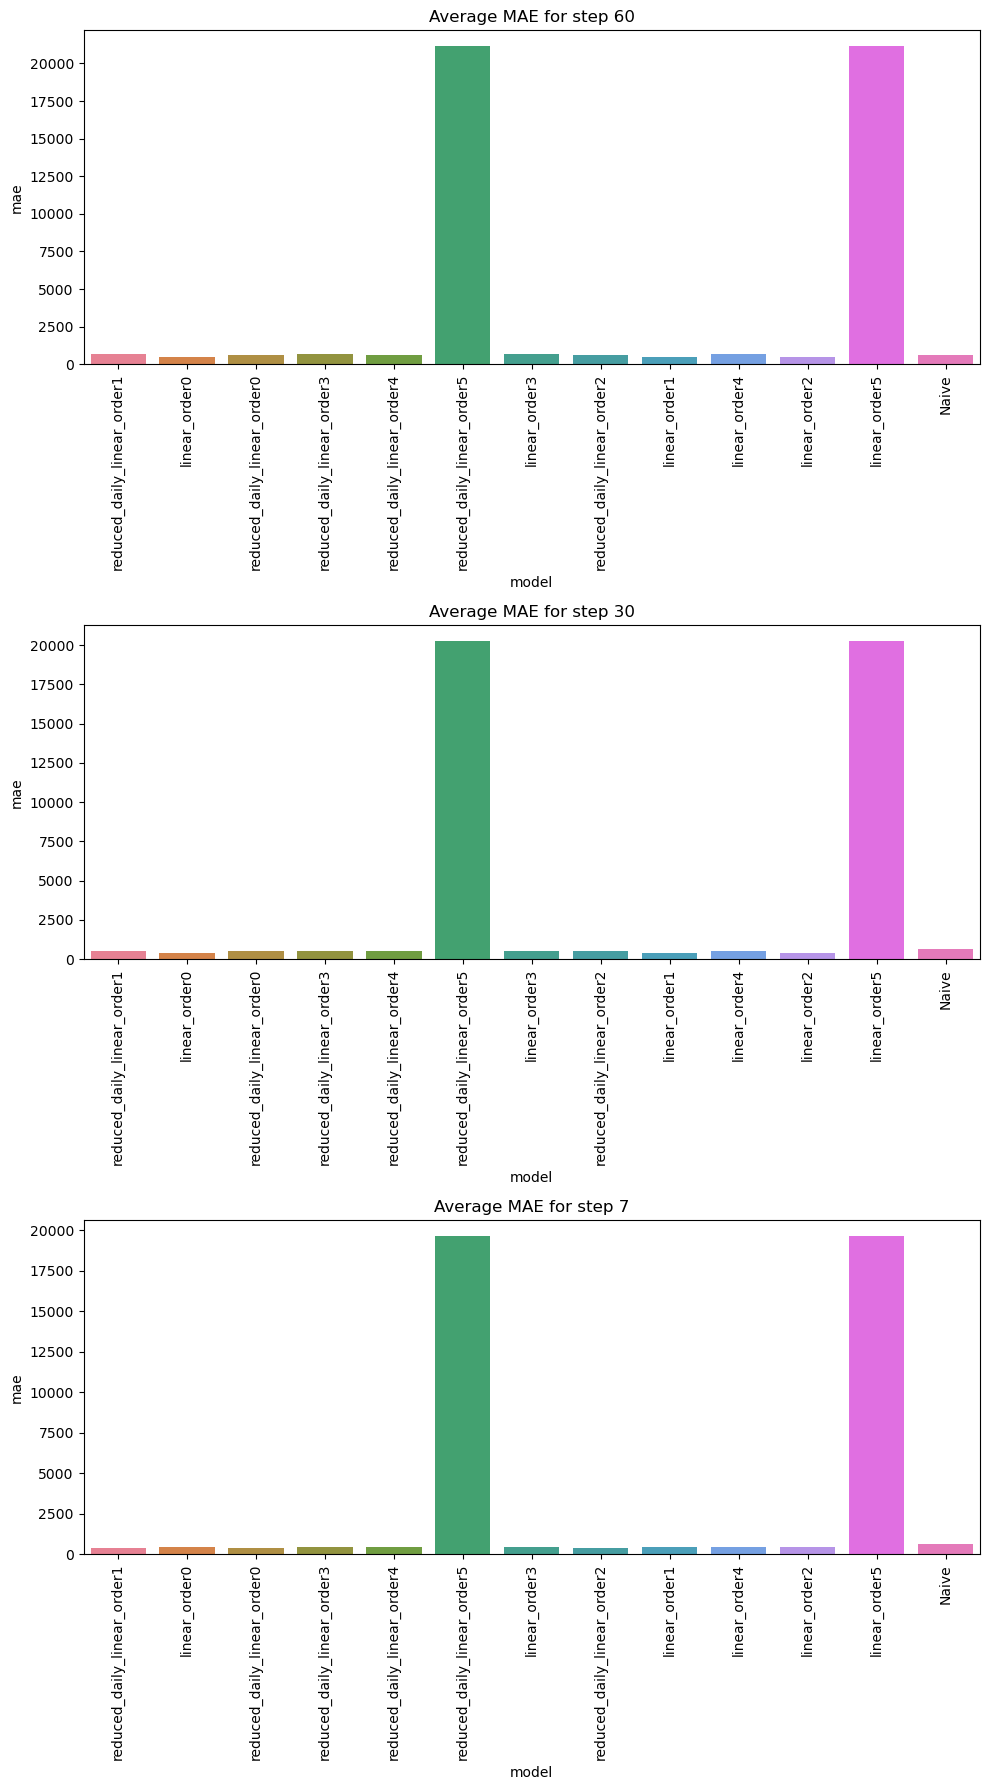

In [37]:
# Run forecasts
run_forecasts(steps, offset_list, offset_to_show, linear_models_loaded, non_linear_models_loaded, naive, time_step, ts_train, ts_test)

In [38]:
# daily hybrid models (note we have kept the variable names as linear when we could change to hybrid but it makes no real difference)

# Steps for the forecast (read config.yml to see and change the steps for the forecast)
steps = config["modelling"]["daily_steps"]

# Offset list
offset_list = config["modelling"]["daily_offset"]

# List of offsets to show the forecasts for
offset_to_show = config["modelling"]["daily_offsets_to_show"]

# Fourier features from extracted features
fourier_features = config["shap"][DAILY_HYBRID_NAME]["extracted_fourier_features"]

# This is where I am going to slightly go against what was found using the top 30 features by mean abs shap value
# For both the daily and hourly time series the linear models didn't have any trend features in the top 30 (same for the linear part of the hybrid models as they are the same).
# This means that the SHAP values are suggesting that the trend features aren't very important for the linear models. However from the modelling
# notebook we do see a significant difference between the linear models based purely on difference in order, so we are going to test for order again but will include an order 0 model
# so just intercept to see whether that model is really superior to the others. (you can find the list in config.yml)
order_list = config["shap"]["daily_hybrid_order_list"]

# Hybrid, the hybrid model we will be using
hybrid = XGBRegressor(
        n_estimators=config["xgboost_default"]["n_estimators"],
        learning_rate=config["xgboost_default"]["learning_rate"],
        max_depth=config["xgboost_default"]["max_depth"],
        subsample=config["xgboost_default"]["subsample"],
        colsample_bytree=config["xgboost_default"]["colsample_bytree"],
        random_state=config["xgboost_setup"]["random_state"],
        eval_metric=config["xgboost_setup"]["eval_metric"],
        tree_method=config["xgboost_setup"]["tree_method"],
        device=config["xgboost_setup"]["device"]
)

# Time step of the series
time_step = "D"

# Time series to use for training
ts_train = ts_daily_train

# Time series to use for testing
ts_test = ts_daily_test

# Lags for training from the extracted features
lags = config["shap"][DAILY_HYBRID_NAME]["extracted_lags"]

# Old lags list (this needs to be appened to the old models for when we forecast)
old_lags = daily_lags

# Linear name list (list of names for the linear models)
names_linear = [f"{config['model_naming']['reduced_daily_hybrid_model_prefix']}{i}" for i in order_list]

# Non linear name list 
names_non_linear = []

# Signature for the file names (this will be how we keep track of which files belong to which models when it comes to hyperparamter tuning)
sig = config["model_sigs"]["daily_hybrid_reduced"]

# Naive baseline (bool to determine whether or not to inlcude a naive baseline in the plots, the naive baseline will just predict time step value t as time step value t-1)
naive = True



In [39]:
# Create train and save the models
create_train_save_models(names_linear, names_non_linear, hybrid, sig, order_list, lags, fourier_features, time_step, ts_train)

In [40]:
# Load the models (and the deterministic processes)
linear_models_loaded, non_linear_models_loaded = load_models(sig)

# Load the previous linear model
old_linear_models_loaded, old_non_linear_models_loaded = load_models(config["model_sigs"]["daily_hybrid"])

# Add the older non_linear_model to the new one
linear_models_loaded = {**linear_models_loaded, **old_linear_models_loaded}

MAE: 448.46 for step = 7, model = reduced_daily_hybrid_order0
MAE: 352.41 for step = 7, model = reduced_daily_hybrid_order1
MAE: 342.50 for step = 7, model = reduced_daily_hybrid_order2
MAE: 254.49 for step = 7, model = reduced_daily_hybrid_order3
MAE: 356.62 for step = 7, model = hybrid_order0
MAE: 384.29 for step = 7, model = hybrid_order1
MAE: 384.87 for step = 7, model = hybrid_order2
MAE: 407.92 for step = 7, model = hybrid_order3
MAE: 621.71 for step =  30, model = Naive



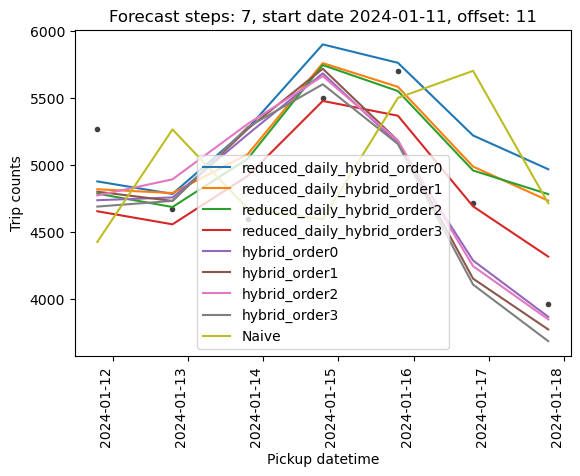

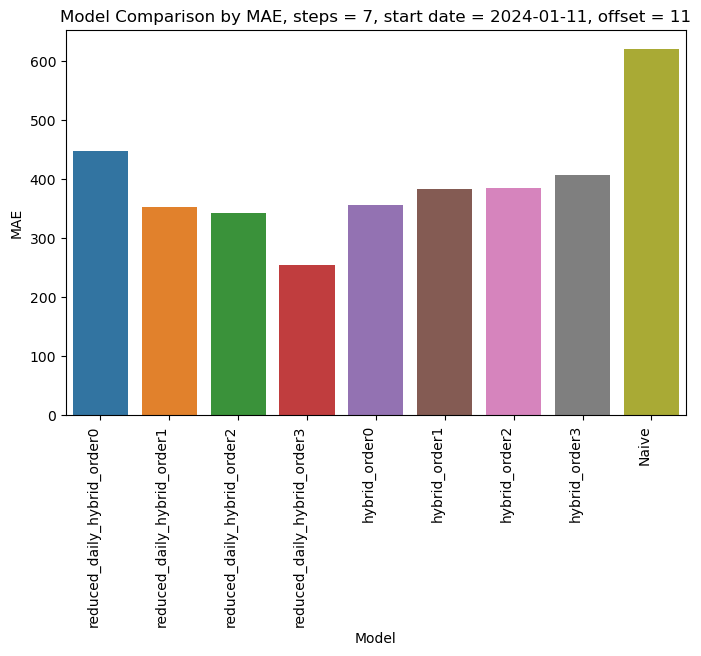

MAE: 389.09 for step = 30, model = reduced_daily_hybrid_order0
MAE: 305.29 for step = 30, model = reduced_daily_hybrid_order1
MAE: 324.37 for step = 30, model = reduced_daily_hybrid_order2
MAE: 461.95 for step = 30, model = reduced_daily_hybrid_order3
MAE: 301.72 for step = 30, model = hybrid_order0
MAE: 284.74 for step = 30, model = hybrid_order1
MAE: 297.52 for step = 30, model = hybrid_order2
MAE: 294.29 for step = 30, model = hybrid_order3
MAE: 637.10 for step =  30, model = Naive



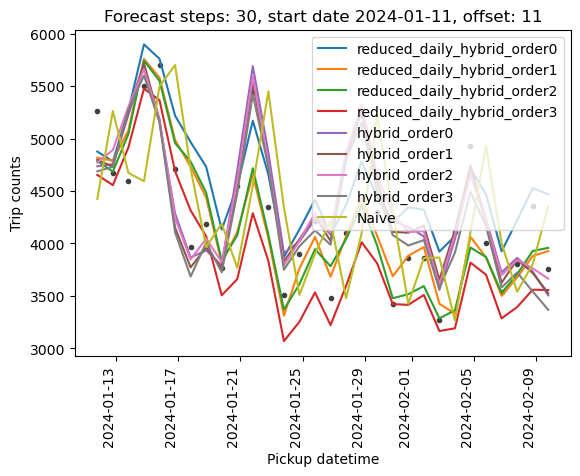

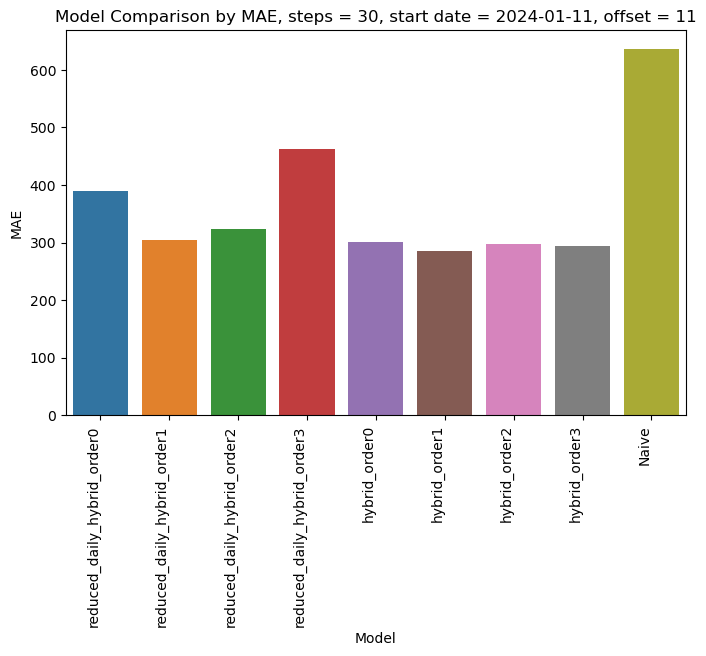

MAE: 486.93 for step = 60, model = reduced_daily_hybrid_order0
MAE: 389.70 for step = 60, model = reduced_daily_hybrid_order1
MAE: 400.17 for step = 60, model = reduced_daily_hybrid_order2
MAE: 683.43 for step = 60, model = reduced_daily_hybrid_order3
MAE: 399.69 for step = 60, model = hybrid_order0
MAE: 324.40 for step = 60, model = hybrid_order1
MAE: 354.97 for step = 60, model = hybrid_order2
MAE: 327.82 for step = 60, model = hybrid_order3
MAE: 607.33 for step =  30, model = Naive



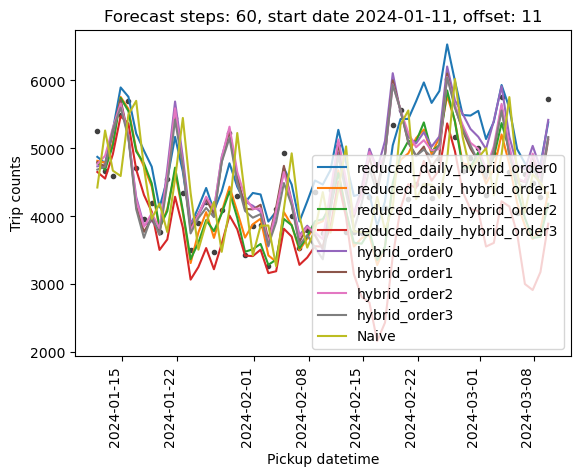

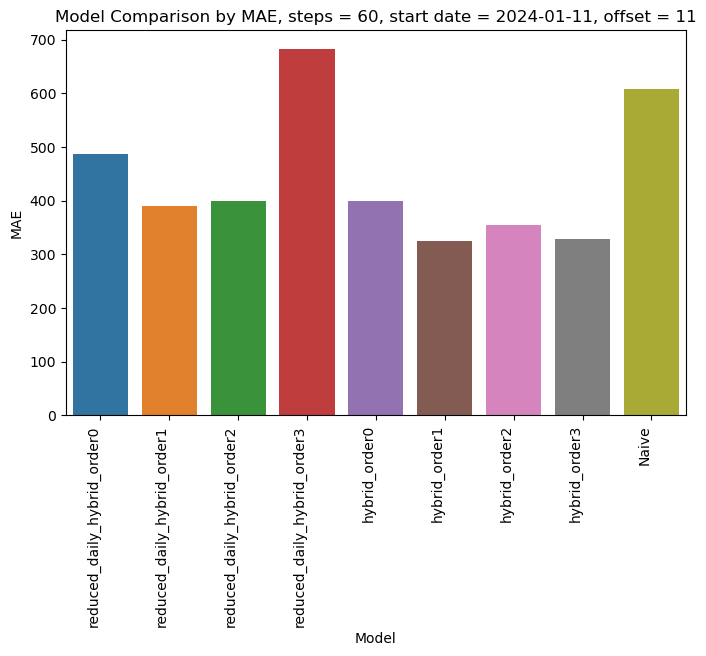


Average MAE scores for step 60:
reduced_daily_hybrid_order1, average MAE: 829.75
hybrid_order1, average MAE: 537.62
reduced_daily_hybrid_order2, average MAE: 698.82
hybrid_order3, average MAE: 563.80
hybrid_order2, average MAE: 526.40
reduced_daily_hybrid_order0, average MAE: 527.81
reduced_daily_hybrid_order3, average MAE: 866.40
hybrid_order0, average MAE: 482.23
Naive, average MAE: 640.27

Average MAE scores for step 30:
reduced_daily_hybrid_order1, average MAE: 612.21
hybrid_order1, average MAE: 451.28
reduced_daily_hybrid_order2, average MAE: 567.69
hybrid_order3, average MAE: 477.07
hybrid_order2, average MAE: 444.43
reduced_daily_hybrid_order0, average MAE: 468.81
reduced_daily_hybrid_order3, average MAE: 655.03
hybrid_order0, average MAE: 420.74
Naive, average MAE: 630.26

Average MAE scores for step 7:
reduced_daily_hybrid_order1, average MAE: 593.76
hybrid_order1, average MAE: 494.93
reduced_daily_hybrid_order2, average MAE: 576.95
hybrid_order3, average MAE: 496.31
hybrid_o

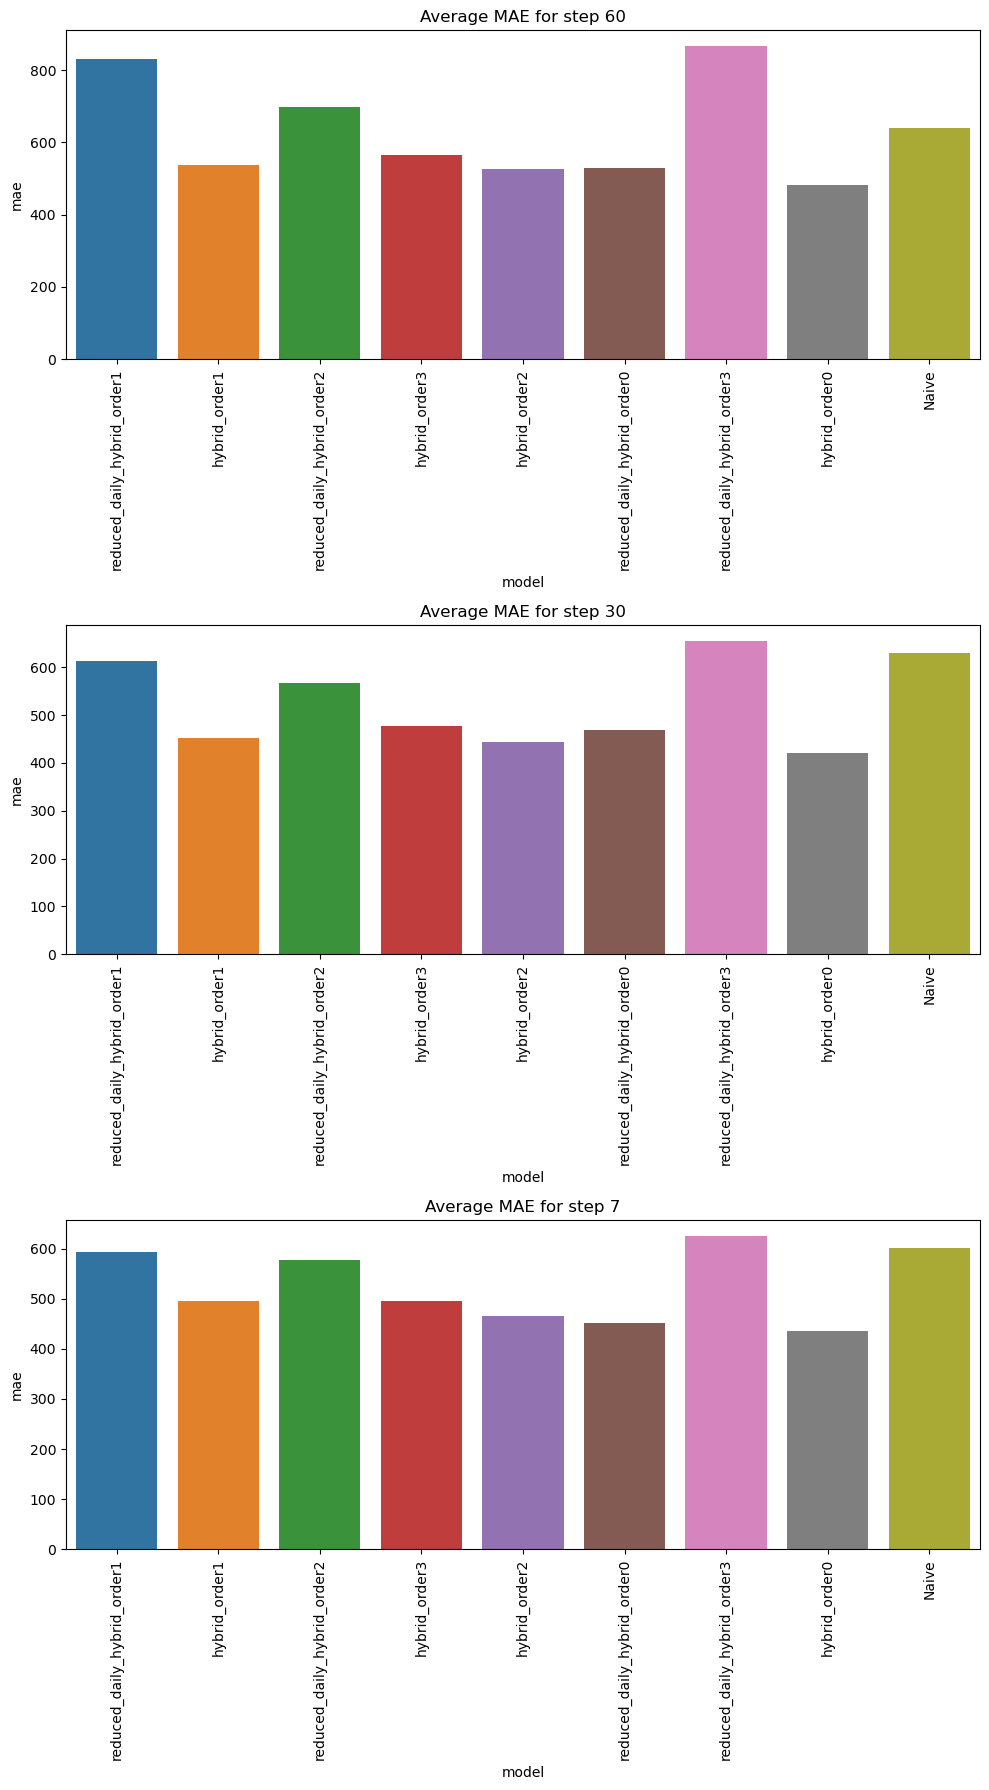

In [41]:
# Run forecasts
run_forecasts(steps, offset_list, offset_to_show, linear_models_loaded, non_linear_models_loaded, naive, time_step, ts_train, ts_test)


In [42]:
# Now time for the hourly models
# First up is the hourly non linear model

# Steps for the forecast (read config.yml to see and change the steps for the forecast)
steps = config["modelling"]["hourly_steps"]

# Offset list
offset_list = config["modelling"]["hourly_offset"]

# List of offsets to show the forecasts for
offset_to_show = config["modelling"]["hourly_offsets_to_show"]

# Fourier features from extracted features
fourier_features = config["shap"][HOURLY_NON_LINEAR_NAME]["extracted_fourier_features"]

# List of trend orders for our linear models, as we aren't using any linear models just set empty 
order_list = []

# Hybrid, the hybrid model we will be using
hybrid = None

# Time step of the series
time_step = "h"

# Time series to use for training
ts_train = ts_hourly_train

# Time series to use for testing
ts_test = ts_hourly_test

# Lags for training from the extracted features
lags = config["shap"][HOURLY_NON_LINEAR_NAME]["extracted_lags"]

# Old lags list (this needs to be appened to the old models for when we forecast)
old_lags = used_hourly_lags

# Linear name list (list of names for the linear models)
names_linear = []

# Non linear name list 
names_non_linear = [config["model_naming"]["reduced_hourly_non_linear_model_prefix"]]

# Signature for the file names (this will be how we keep track of which files belong to which models when it comes to hyperparamter tuning)
sig = config["model_sigs"]["hourly_non_linear_reduced"]

# Naive baseline (bool to determine whether or not to inlcude a naive baseline in the plots, the naive baseline will just predict time step value t as time step value t-1)
naive = True



In [43]:
# Create train and save the models
create_train_save_models(names_linear, names_non_linear, hybrid, sig, order_list, lags, fourier_features, time_step, ts_train)

In [44]:
# Load the models (and the deterministic processes)
linear_models_loaded, non_linear_models_loaded = load_models(sig)

# Load the previous non linear model
old_linear_models_loaded, old_non_linear_models_loaded = load_models(config["model_sigs"]["hourly_linear"])

# Add the older non_linear_model to the new one
non_linear_models_loaded = {**old_non_linear_models_loaded, **non_linear_models_loaded}

MAE: 26.42 for step = 24, model = base_non_linear
MAE: 30.71 for step = 24, model = reduced_hourly_non_linear
MAE: 47.88 for step =  30, model = Naive



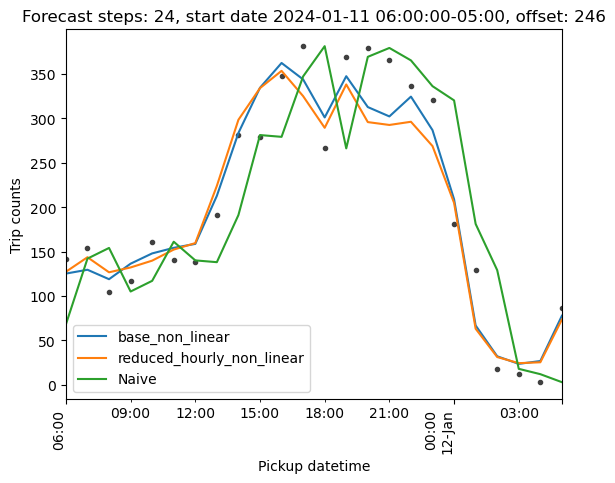

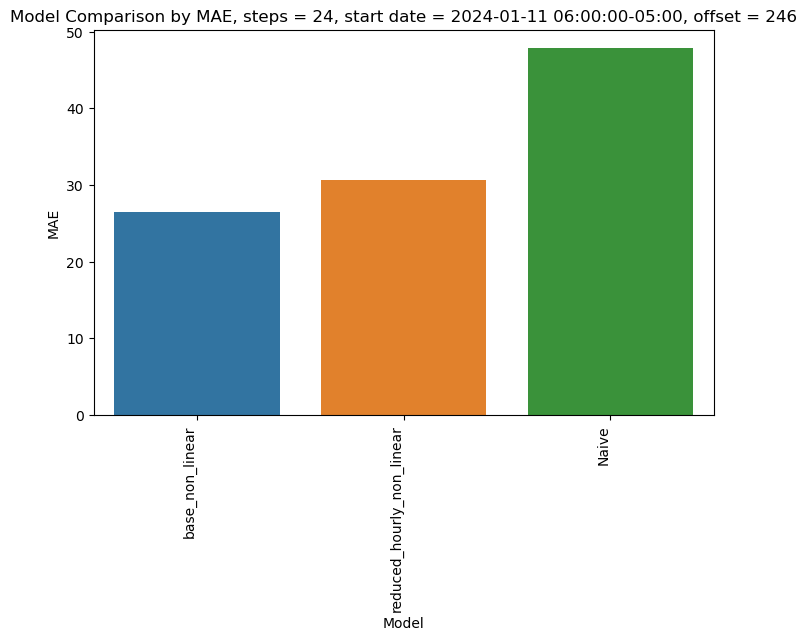

MAE: 33.11 for step = 168, model = base_non_linear
MAE: 34.32 for step = 168, model = reduced_hourly_non_linear
MAE: 52.86 for step =  30, model = Naive



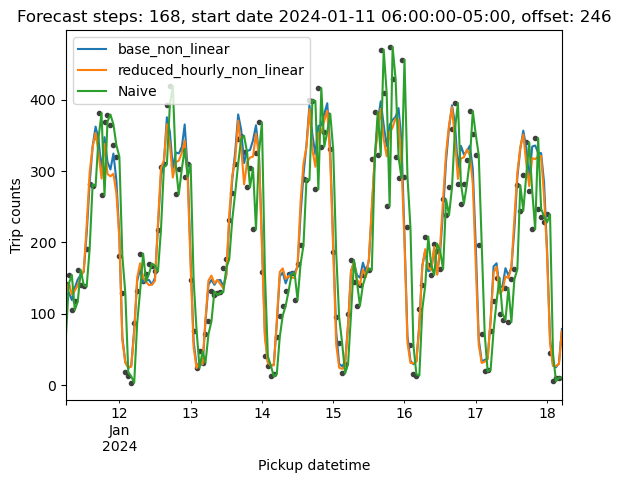

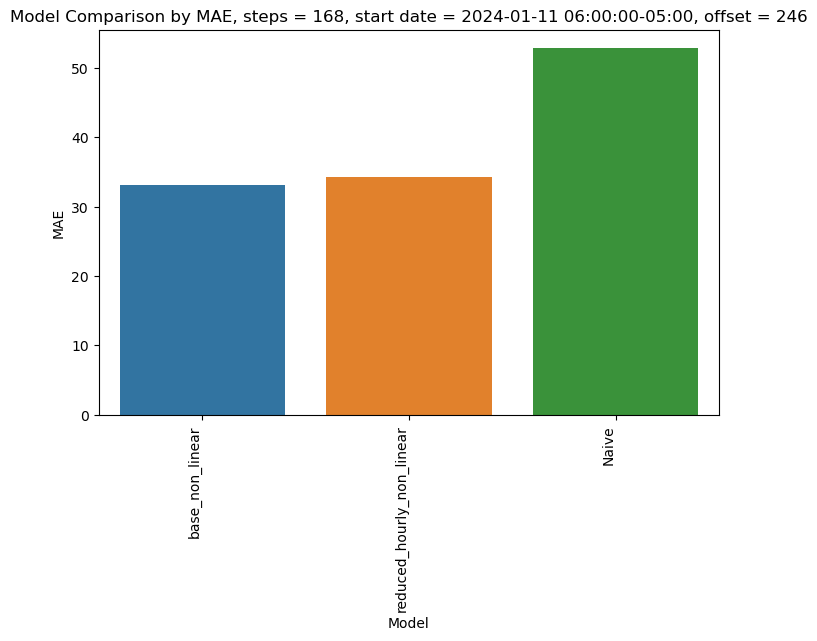

MAE: 45.32 for step = 720, model = base_non_linear
MAE: 42.38 for step = 720, model = reduced_hourly_non_linear
MAE: 46.96 for step =  30, model = Naive



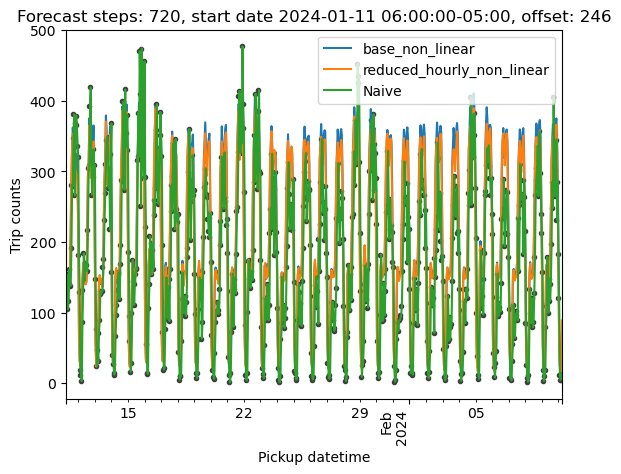

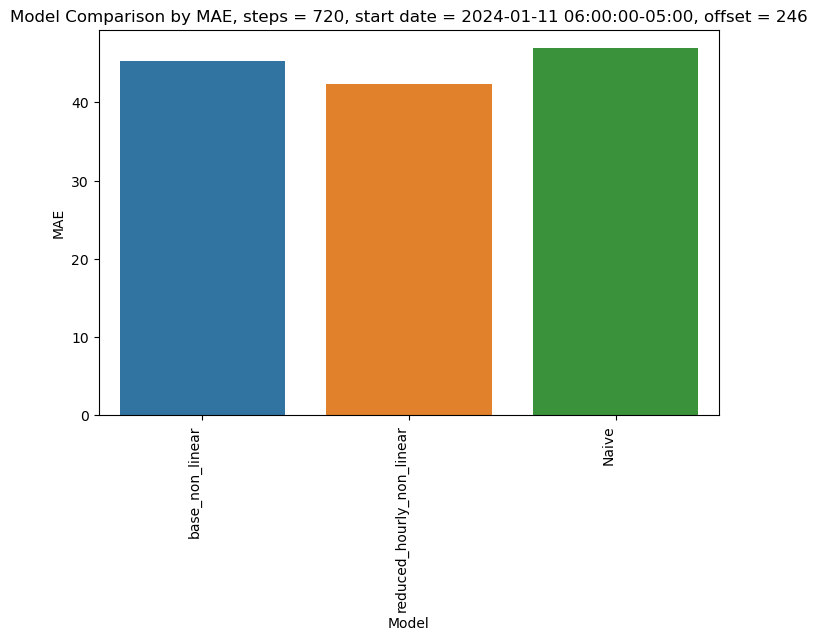


Average MAE scores for step 24:
base_non_linear, average MAE: 32.24
reduced_hourly_non_linear, average MAE: 31.88
Naive, average MAE: 50.61

Average MAE scores for step 168:
base_non_linear, average MAE: 34.45
reduced_hourly_non_linear, average MAE: 34.92
Naive, average MAE: 53.16

Average MAE scores for step 720:
base_non_linear, average MAE: 39.34
reduced_hourly_non_linear, average MAE: 39.70
Naive, average MAE: 54.01


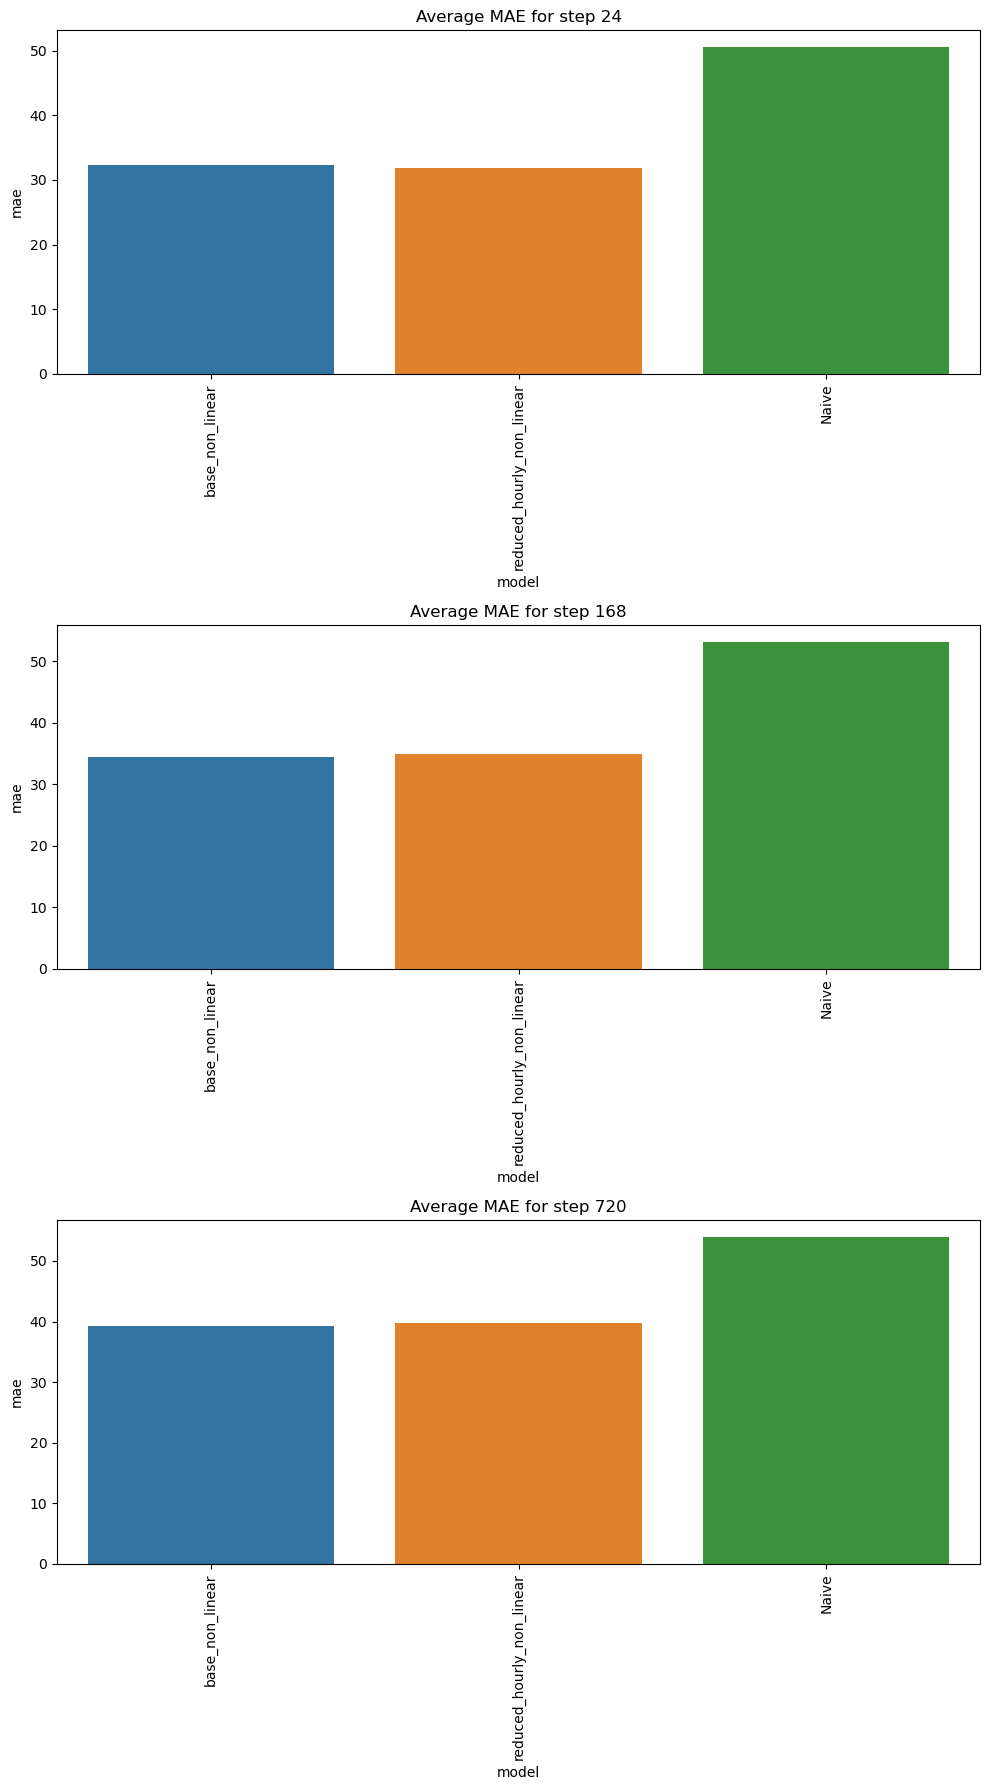

In [45]:
# Run forecasts
run_forecasts(steps, offset_list, offset_to_show, linear_models_loaded, non_linear_models_loaded, naive, time_step, ts_train, ts_test)

In [46]:
# hourly linear models

# Steps for the forecast (read config.yml to see and change the steps for the forecast)
steps = config["modelling"]["hourly_steps"]

# Offset list
offset_list = config["modelling"]["hourly_offset"]

# List of offsets to show the forecasts for
offset_to_show = config["modelling"]["hourly_offsets_to_show"]

# Fourier features from extracted features
fourier_features = config["shap"][HOURLY_LINEAR_NAME]["extracted_fourier_features"]

# This is where I am going to slightly go against what was found using the top 30 features by mean abs shap value
# For both the daily and hourly time series the linear models didn't have any trend features in the top 30 (same for the linear part of the hybrid models as they are the same).
# This means that the SHAP values are suggesting that the trend features aren't very important for the linear models. However from the modelling
# notebook we do see a significant difference between the linear models based purely on difference in order, so we are going to test for order again but will include an order 0 model
# so just intercept to see whether that model is really superior to the others. (you can find the list in config.yml)
order_list = config["shap"]["daily_order_list"] # the order lists are the same daily and hourly

# Hybrid, the hybrid model we will be using
hybrid = None

# Time step of the series
time_step = "h"

# Time series to use for training
ts_train = ts_hourly_train

# Time series to use for testing
ts_test = ts_hourly_test

# Lags for training from the extracted features
lags = config["shap"][HOURLY_LINEAR_NAME]["extracted_lags"]

# Old lags list (this needs to be appened to the old models for when we forecast)
old_lags = used_hourly_lags

# Linear name list (list of names for the linear models)
names_linear = [f"{config['model_naming']['reduced_hourly_linear_model_prefix']}{i}" for i in order_list]

# Non linear name list 
names_non_linear = []

# Signature for the file names (this will be how we keep track of which files belong to which models when it comes to hyperparamter tuning)
sig = config["model_sigs"]["hourly_linear_reduced"]

# Naive baseline (bool to determine whether or not to inlcude a naive baseline in the plots, the naive baseline will just predict time step value t as time step value t-1)
naive = True

In [47]:
# Create train and save the models
create_train_save_models(names_linear, names_non_linear, hybrid, sig, order_list, lags, fourier_features, time_step, ts_train)

In [48]:
# Load the models (and the deterministic processes)
linear_models_loaded, non_linear_models_loaded = load_models(sig)

# Load the previous linear model
old_linear_models_loaded, old_non_linear_models_loaded = load_models(config["model_sigs"]["hourly_linear"])

# Add the older non_linear_model to the new one
linear_models_loaded = {**linear_models_loaded, **old_linear_models_loaded}

MAE: 28.34 for step = 24, model = reduced_hourly_linear_order0
MAE: 29.65 for step = 24, model = reduced_hourly_linear_order1
MAE: 32.63 for step = 24, model = reduced_hourly_linear_order2
MAE: 209.05 for step = 24, model = reduced_hourly_linear_order3
MAE: 198.16 for step = 24, model = reduced_hourly_linear_order4
MAE: 176.39 for step = 24, model = reduced_hourly_linear_order5
MAE: 26.62 for step = 24, model = linear_order0
MAE: 26.69 for step = 24, model = linear_order1
MAE: 27.31 for step = 24, model = linear_order2
MAE: 209.05 for step = 24, model = linear_order3
MAE: 198.16 for step = 24, model = linear_order4
MAE: 176.39 for step = 24, model = linear_order5
MAE: 47.88 for step =  30, model = Naive



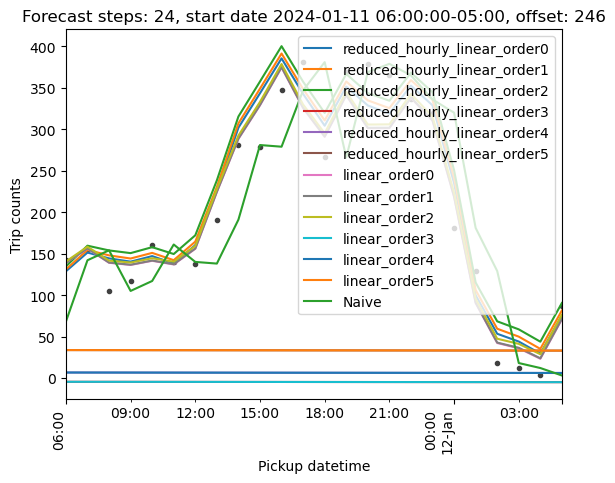

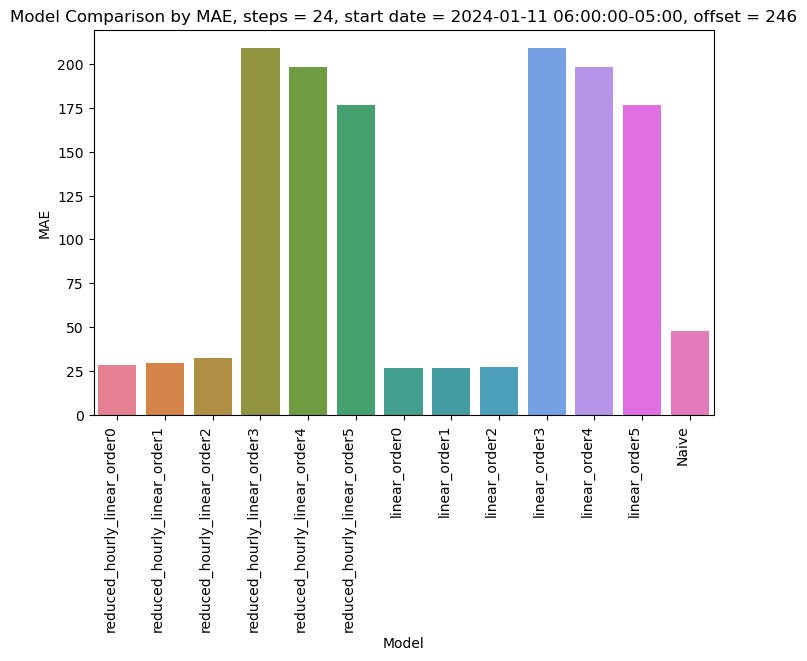

MAE: 33.08 for step = 168, model = reduced_hourly_linear_order0
MAE: 35.63 for step = 168, model = reduced_hourly_linear_order1
MAE: 41.67 for step = 168, model = reduced_hourly_linear_order2
MAE: 213.29 for step = 168, model = reduced_hourly_linear_order3
MAE: 202.57 for step = 168, model = reduced_hourly_linear_order4
MAE: 178.68 for step = 168, model = reduced_hourly_linear_order5
MAE: 31.84 for step = 168, model = linear_order0
MAE: 31.94 for step = 168, model = linear_order1
MAE: 33.77 for step = 168, model = linear_order2
MAE: 213.29 for step = 168, model = linear_order3
MAE: 202.57 for step = 168, model = linear_order4
MAE: 178.68 for step = 168, model = linear_order5
MAE: 52.86 for step =  30, model = Naive



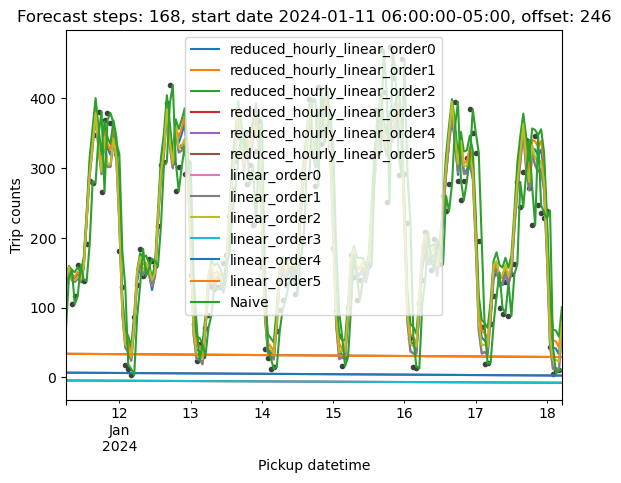

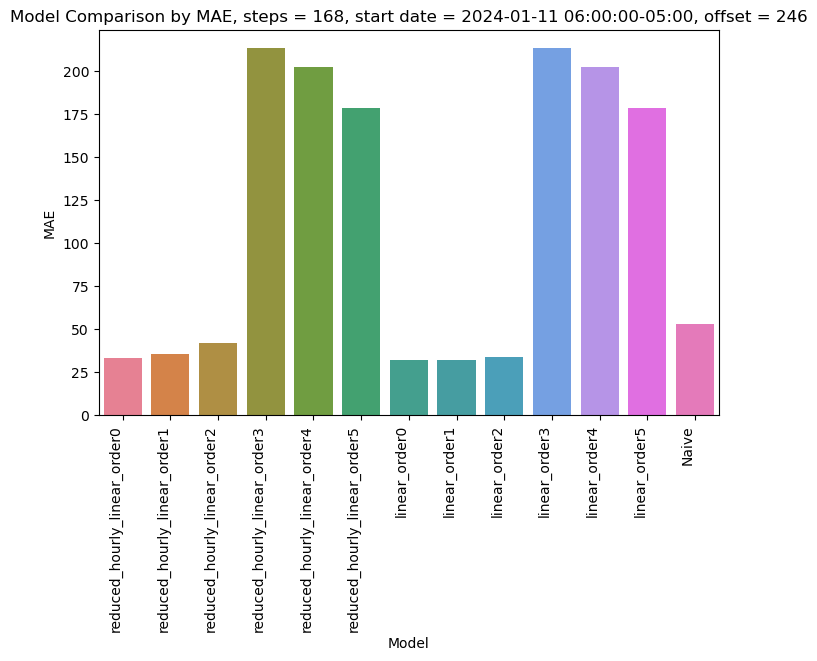

MAE: 33.91 for step = 720, model = reduced_hourly_linear_order0
MAE: 45.43 for step = 720, model = reduced_hourly_linear_order1
MAE: 68.56 for step = 720, model = reduced_hourly_linear_order2
MAE: 190.57 for step = 720, model = reduced_hourly_linear_order3
MAE: 181.36 for step = 720, model = reduced_hourly_linear_order4
MAE: 158.19 for step = 720, model = reduced_hourly_linear_order5
MAE: 30.04 for step = 720, model = linear_order0
MAE: 31.08 for step = 720, model = linear_order1
MAE: 45.39 for step = 720, model = linear_order2
MAE: 190.57 for step = 720, model = linear_order3
MAE: 181.36 for step = 720, model = linear_order4
MAE: 158.19 for step = 720, model = linear_order5
MAE: 46.96 for step =  30, model = Naive



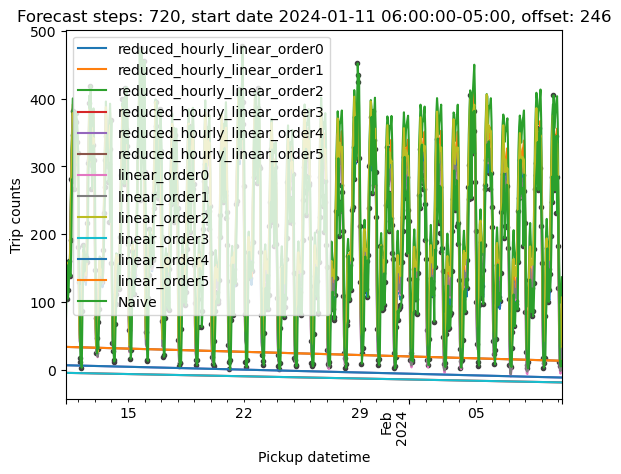

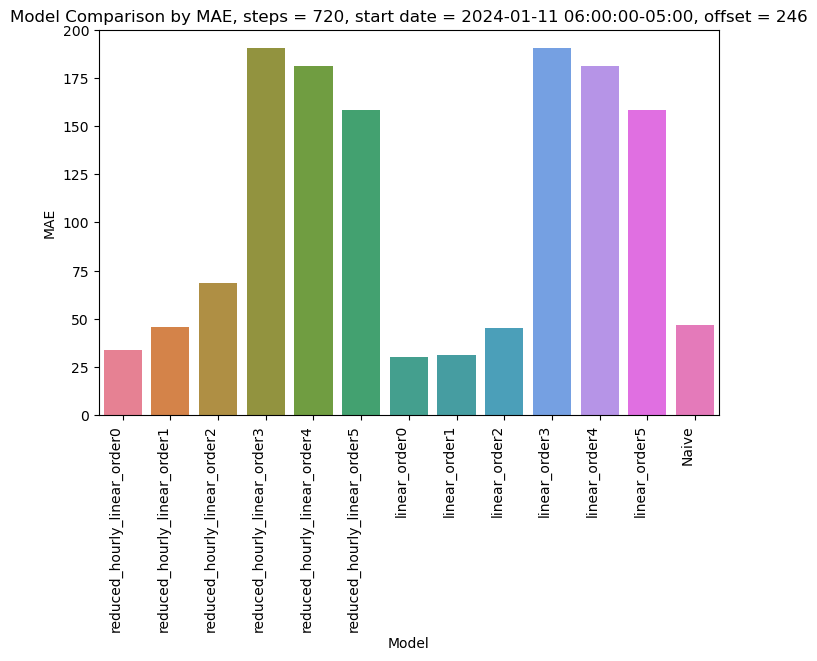


Average MAE scores for step 24:
linear_order2, average MAE: 32.40
linear_order0, average MAE: 31.37
reduced_hourly_linear_order1, average MAE: 33.48
reduced_hourly_linear_order2, average MAE: 36.92
reduced_hourly_linear_order0, average MAE: 32.75
reduced_hourly_linear_order3, average MAE: 348.83
linear_order3, average MAE: 348.82
linear_order4, average MAE: 386.24
reduced_hourly_linear_order4, average MAE: 386.24
reduced_hourly_linear_order5, average MAE: 397.11
linear_order1, average MAE: 31.43
linear_order5, average MAE: 397.11
Naive, average MAE: 50.61

Average MAE scores for step 168:
linear_order2, average MAE: 36.41
linear_order0, average MAE: 34.72
reduced_hourly_linear_order1, average MAE: 36.59
reduced_hourly_linear_order2, average MAE: 41.95
reduced_hourly_linear_order0, average MAE: 35.99
reduced_hourly_linear_order3, average MAE: 358.38
linear_order3, average MAE: 358.37
linear_order4, average MAE: 396.48
reduced_hourly_linear_order4, average MAE: 396.48
reduced_hourly_lin

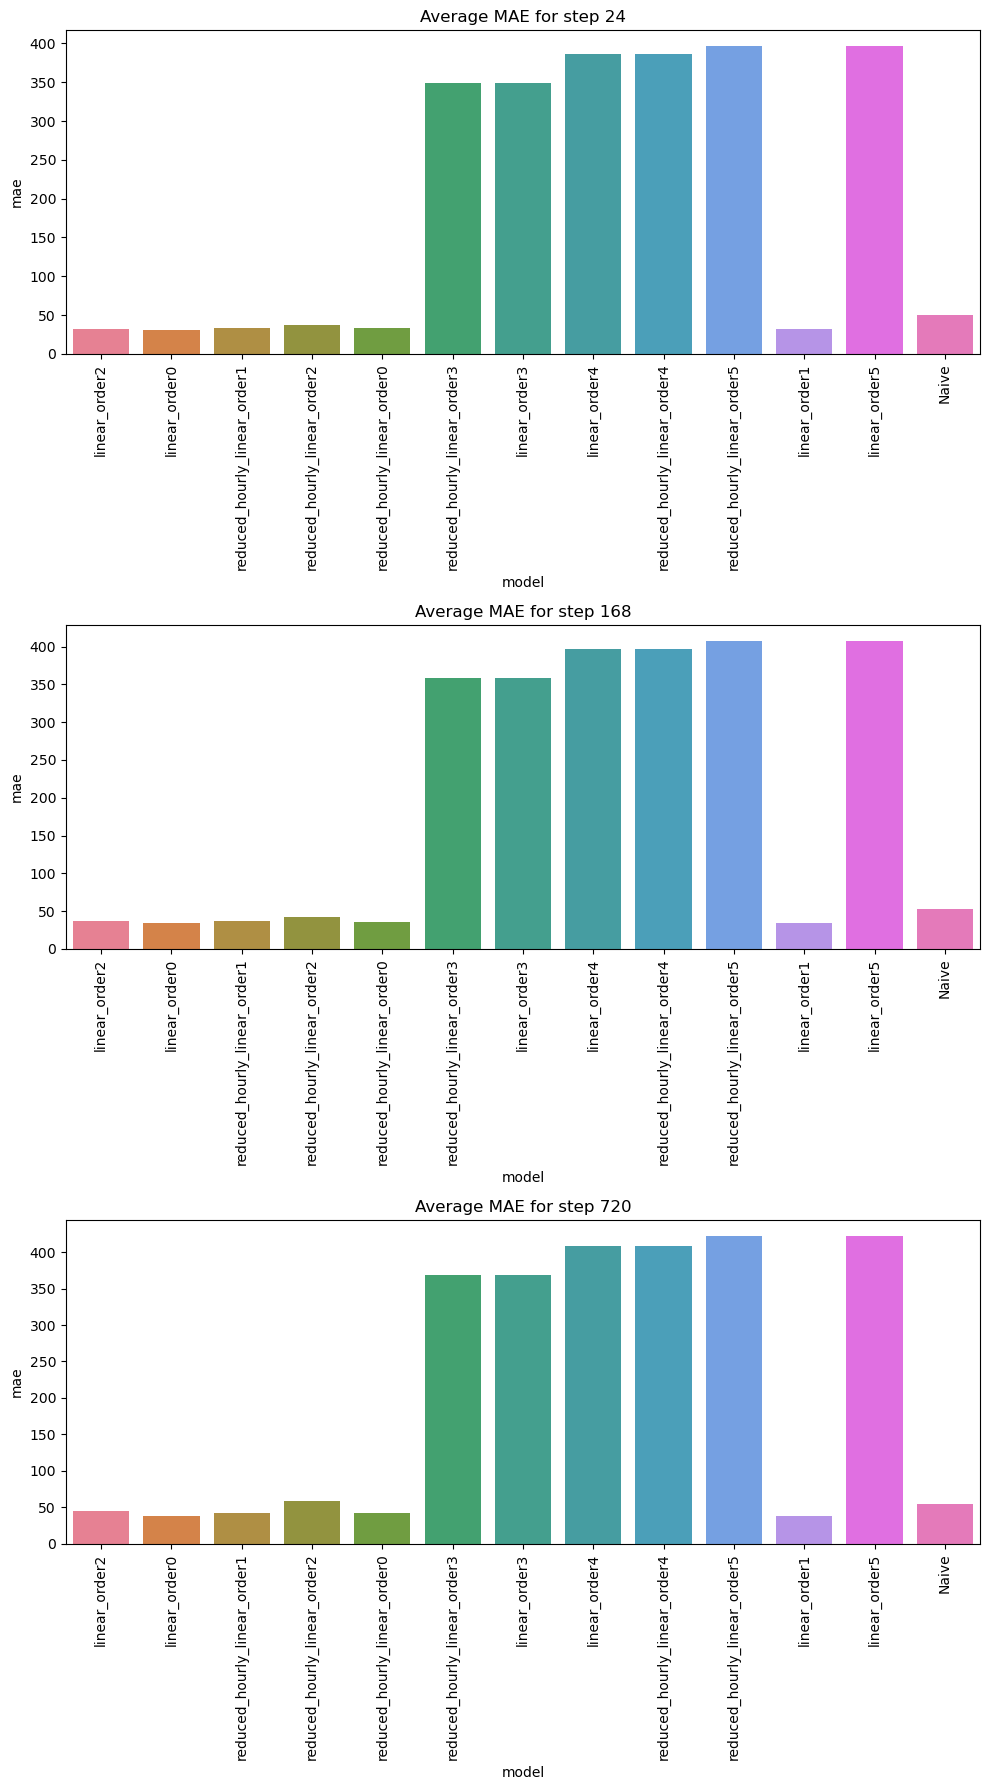

In [49]:
# Run forecasts
run_forecasts(steps, offset_list, offset_to_show, linear_models_loaded, non_linear_models_loaded, naive, time_step, ts_train, ts_test)

In [50]:
# hourly hybrid models 
 
# Steps for the forecast (read config.yml to see and change the steps for the forecast)
steps = config["modelling"]["hourly_steps"]

# Offset list
offset_list = config["modelling"]["hourly_offset"]

# List of offsets to show the forecasts for
offset_to_show = config["modelling"]["hourly_offsets_to_show"]

# Fourier features from extracted features
fourier_features = config["shap"][HOURLY_HYBRID_NAME]["extracted_fourier_features"]

# This is where I am going to slightly go against what was found using the top 30 features by mean abs shap value
# For both the daily and hourly time series the linear models didn't have any trend features in the top 30 (same for the linear part of the hybrid models as they are the same).
# This means that the SHAP values are suggesting that the trend features aren't very important for the linear models. However from the modelling
# notebook we do see a significant difference between the linear models based purely on difference in order, so we are going to test for order again but will include an order 0 model
# so just intercept to see whether that model is really superior to the others. (you can find the list in config.yml)
order_list = config["shap"]["daily_hybrid_order_list"]

# Hybrid, the hybrid model we will be using
hybrid = XGBRegressor(
        n_estimators=config["xgboost_default"]["n_estimators"],
        learning_rate=config["xgboost_default"]["learning_rate"],
        max_depth=config["xgboost_default"]["max_depth"],
        subsample=config["xgboost_default"]["subsample"],
        colsample_bytree=config["xgboost_default"]["colsample_bytree"],
        random_state=config["xgboost_setup"]["random_state"],
        eval_metric=config["xgboost_setup"]["eval_metric"],
        tree_method=config["xgboost_setup"]["tree_method"],
        device=config["xgboost_setup"]["device"]
)

# Time step of the series
time_step = "h"

# Time series to use for training
ts_train = ts_hourly_train

# Time series to use for testing
ts_test = ts_hourly_test

# Lags for training from the extracted features
lags = config["shap"][HOURLY_HYBRID_NAME]["extracted_lags"]

# Old lags list (this needs to be appened to the old models for when we forecast)
old_lags = used_hourly_lags

# Linear name list (list of names for the linear models)
names_linear = [f"{config['model_naming']['reduced_hourly_hybrid_model_prefix']}{i}" for i in order_list]

# Non linear name list 
names_non_linear = []

# Signature for the file names (this will be how we keep track of which files belong to which models when it comes to hyperparamter tuning)
sig = config["model_sigs"]["hourly_hybrid_reduced"]

# Naive baseline (bool to determine whether or not to inlcude a naive baseline in the plots, the naive baseline will just predict time step value t as time step value t-1)
naive = True




In [51]:
# Create train and save the models
create_train_save_models(names_linear, names_non_linear, hybrid, sig, order_list, lags, fourier_features, time_step, ts_train)

In [52]:
# Load the models (and the deterministic processes)
linear_models_loaded, non_linear_models_loaded = load_models(sig)

# Load the previous linear model
old_linear_models_loaded, old_non_linear_models_loaded = load_models(config["model_sigs"]["hourly_hybrid"])

# Add the older non_linear_model to the new one
linear_models_loaded = {**linear_models_loaded, **old_linear_models_loaded}

MAE: 27.03 for step = 24, model = reduced_hourly_hybrid_order0
MAE: 27.98 for step = 24, model = reduced_hourly_hybrid_order1
MAE: 28.27 for step = 24, model = reduced_hourly_hybrid_order2
MAE: 35.84 for step = 24, model = reduced_hourly_hybrid_order3
MAE: 27.49 for step = 24, model = hybrid_order0
MAE: 26.72 for step = 24, model = hybrid_order1
MAE: 27.69 for step = 24, model = hybrid_order2
MAE: 61.34 for step = 24, model = hybrid_order3
MAE: 47.88 for step =  30, model = Naive



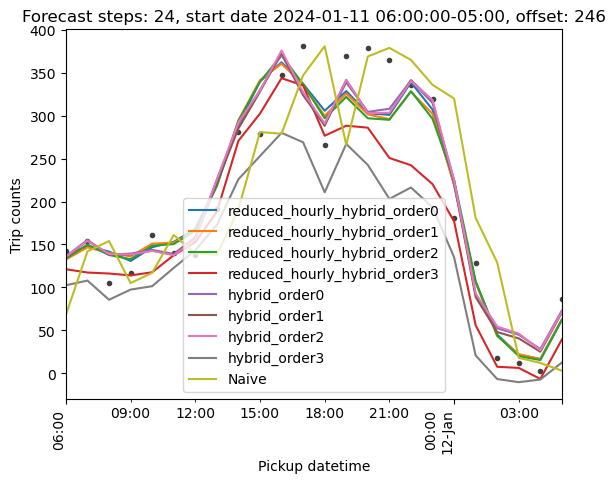

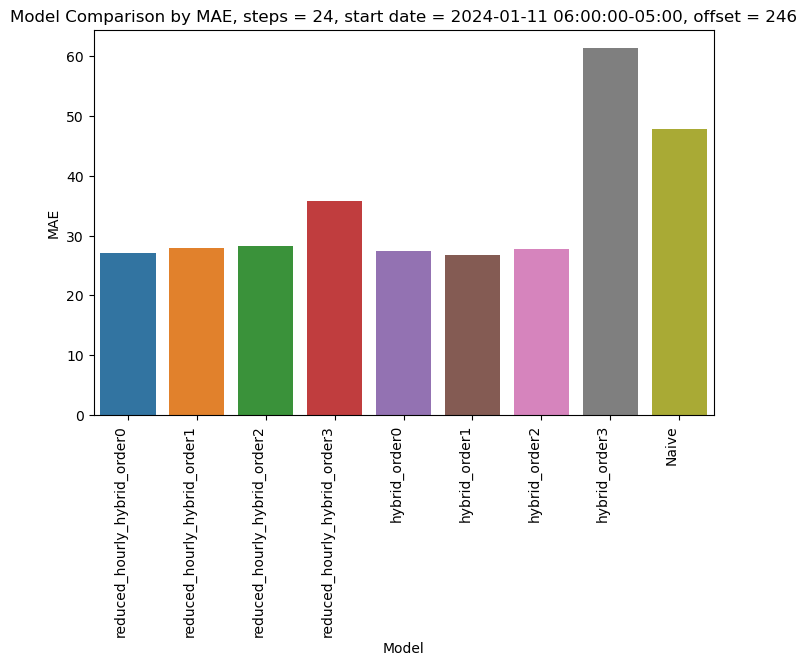

MAE: 32.56 for step = 168, model = reduced_hourly_hybrid_order0
MAE: 32.82 for step = 168, model = reduced_hourly_hybrid_order1
MAE: 33.18 for step = 168, model = reduced_hourly_hybrid_order2
MAE: 47.36 for step = 168, model = reduced_hourly_hybrid_order3
MAE: 33.12 for step = 168, model = hybrid_order0
MAE: 32.67 for step = 168, model = hybrid_order1
MAE: 33.18 for step = 168, model = hybrid_order2
MAE: 85.89 for step = 168, model = hybrid_order3
MAE: 52.86 for step =  30, model = Naive



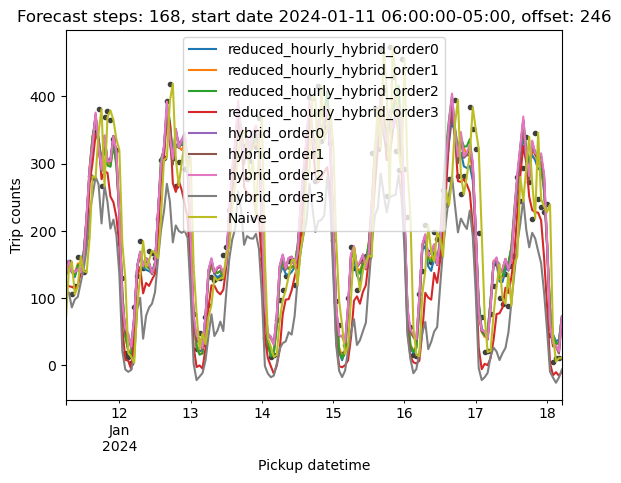

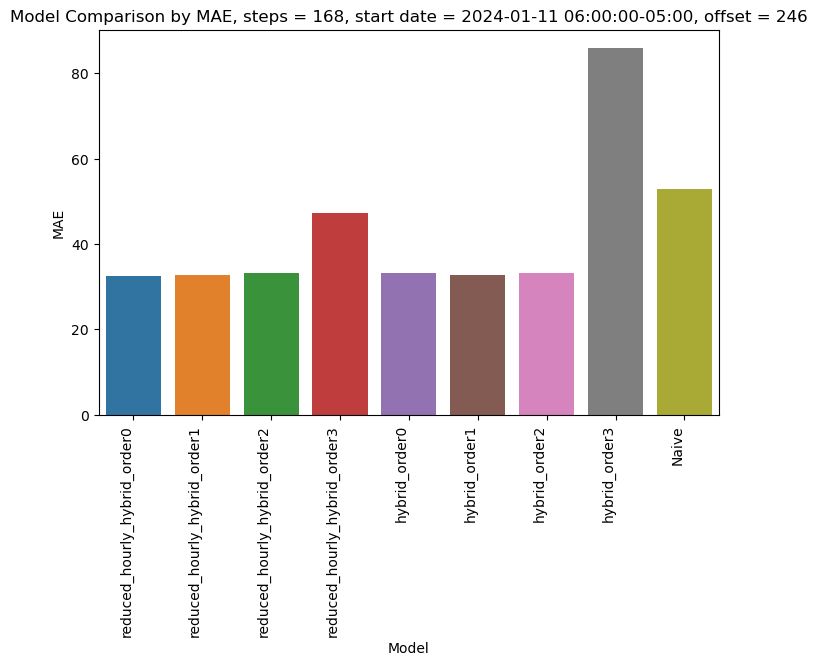

MAE: 34.02 for step = 720, model = reduced_hourly_hybrid_order0
MAE: 32.44 for step = 720, model = reduced_hourly_hybrid_order1
MAE: 31.66 for step = 720, model = reduced_hourly_hybrid_order2
MAE: 113.79 for step = 720, model = reduced_hourly_hybrid_order3
MAE: 43.97 for step = 720, model = hybrid_order0
MAE: 42.70 for step = 720, model = hybrid_order1
MAE: 43.68 for step = 720, model = hybrid_order2
MAE: 96.15 for step = 720, model = hybrid_order3
MAE: 46.96 for step =  30, model = Naive



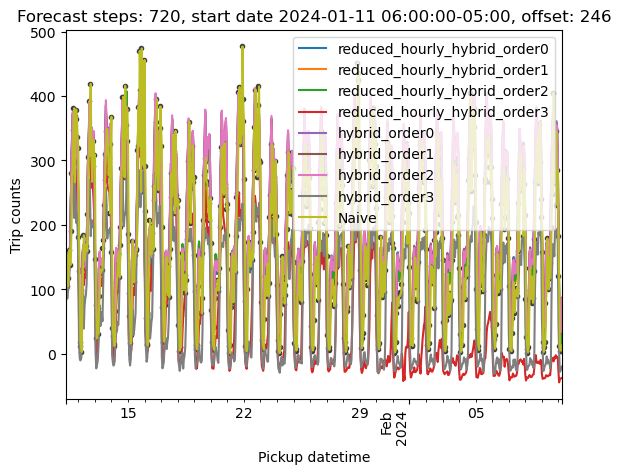

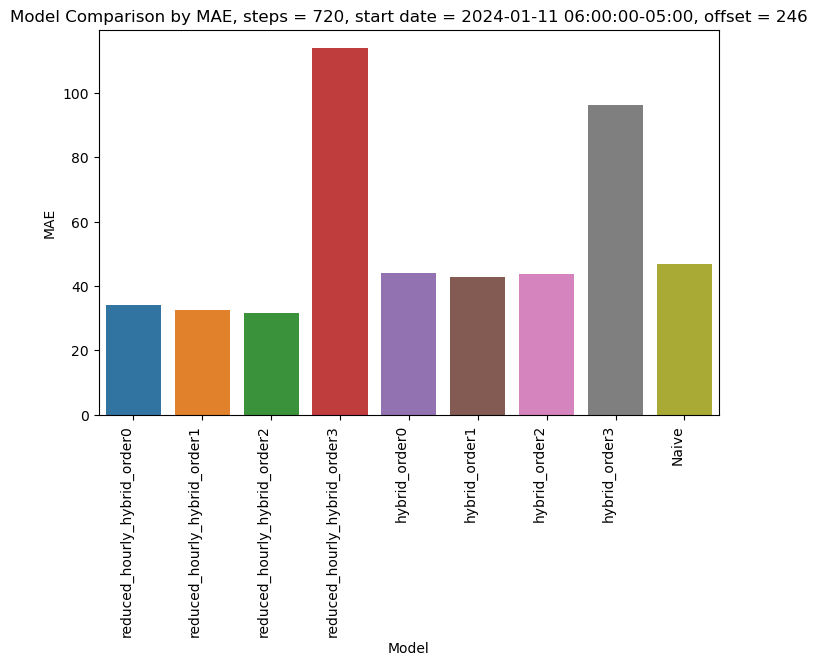

In [ ]:
# Run forecasts
run_forecasts(steps, offset_list, offset_to_show, linear_models_loaded, non_linear_models_loaded, naive, time_step, ts_train, ts_test)



# Conclusions SHAP analysis

The main conclusion from the above plots seems to be that the reduced feature linear models generally perform worse. Whereas the non linear models peform around the same and potentially slightly better. It's a similar story with the hybrid models. 

However there are slight differences between the daily and hourly time series. So for the hourly times series the linear, non linear and hybrid are all very similar when comparing full vs reduced feature sets. But there is slightly more variation for the daily models.

We would like to use the reduced feature sets primarily for XGBoost (so hybrid and non linear) as this will save a lot of time when training the models and potentially make tuning more effective. For the linear models this is potentially less important as they are much easier to fit and what is likely happening is that for the linear models each feature adds a small but significant amount to the prediction. Whereas the non linear model can focus on the smaller feature set to make more accurate trees. 

This trade off would suggest we use the full feature set for linear models and the reduced for hybrid and non linear (as in the hybrid case even though the linear part is being fed a reduced feature set it doesn't seem to increase MAE by as much as in the purely linear case). 

The second key point is what trend will we now use for tuning. The SHAP values suggest that the linear and hybrid models aren't really looking much at the trends, except in the daily hybrid case, where the hybrid model uses order 1 trend. This would suggest that with the exception of daily hybrid it is better to use linear/hybrid_order0 so just a constant with no trend. If we look at the plots this is supported where with the exception of the daily hybrid case the order 0 model is one of the best (usually tied with order 2) if not the best model. In the daily hybrid case it appears that order 3 performs the best both for short and longer term forecasts. So we will select that for hyperparameter tuning. 

So in summary:

daily time series:

reduced non linear,

full linear order 0,

reduced hybrid order 3


hourly time series:

reduced non linear,

full linear order 0,

reduced hybrid order 0


There are a few interesting things we would like to vary when doing our Bayesian hyperparamter optimisation. The first is that we want to both include and exclude COVID from the data we use to tune hyperparamters on.

The reason for this is because during COVID the usual seasonality breaks down dramatically as we get unusal travel patterns. So it may be worth tuning a model on data without COVID as then it is being asseseed more on its ability to pick up the more "normal" patterns within the data. You then have a question of do you use pre or post COVID data, there is more pre COVID data but it will obviously be less relevant for forecasting in the present. Alternatively it may be actually be worth including the COVID data as then the model is tuned to be more robust to "unusal" regimines within the data.

So as it's not clear which of the three will be optimal we will just run all three and then compare the models that hyperopt finds.

For the daily series we wil use a 30 day forecast in our objection function to validate with. For the hourly series we will do a weekly forecast (168 hours).

In [ ]:
# We are going to need to create offsets for the test sets the same way we did in the modelling section
# Max time we can go up to in the test set to ensure we can still forecast
total_daily_time = config["hyperparameter_tuning"]["daily_test_size"] - config["hyperparameter_tuning"]["daily_steps"]

daily_offsets = make_offsets(total_daily_time, config["modelling"]["daily_offset_size"])

config["hyperparameter_tuning"]["daily_offset"] = daily_offsets

total_hourly_time = config["hyperparameter_tuning"]["hourly_test_size"] - config["hyperparameter_tuning"]["hourly_steps"]

hourly_offsets = make_offsets(total_hourly_time, config["modelling"]["hourly_offset_size"])

config["hyperparameter_tuning"]["hourly_offset"] = hourly_offsets

config, PROJECT_ROOT = save_config(config)

In [ ]:
# Dictionary of parameters for Baysian optimisation
bayes_dict = {}

In [ ]:
# Daily non_linear pre, incl and post COVID

# Set the parameters for creat_val_data and the objective function
n_splits = config["hyperparameter_tuning"]["n_splits"]
test_size = config["hyperparameter_tuning"]["daily_test_size"]
lags = config["shap"][DAILY_NON_LINEAR_NAME]["extracted_lags"]
constant = False
order = 0
fourier_features = config["shap"][DAILY_NON_LINEAR_NAME]["extracted_fourier_features"]
time_step = "D"
hybrid = None
steps = config["hyperparameter_tuning"]["daily_steps"]
offset_list = config["hyperparameter_tuning"]["daily_offset"]


# Looping through this dict avoids having to have three separate code cells, the keys are the sigs, values are the tsk
tmp_dict = {
    "daily_non_linear_pre_COVID": ts_daily_train[:"2020-01-01"],
    "daily_non_linear_incl_COVID": ts_daily_train,
    #"daily_non_linear_post_COVID": ts_daily_train["2022-01-01":] # We can't include post COVID as there is too little data to generate yearly lags
}

# Add to Bayes dict
for key, value in tmp_dict.items():
    bayes_dict[key] = {
        "n_splits" : n_splits,
        "test_size" : test_size,
        "lags" : lags,
        "constant" : constant,
        "order" : order,
        "fourier_features" : fourier_features,
        "time_step" : time_step,
        "ts" : value,
        "hybrid" : hybrid,
        "steps" : steps,
        "offset_list" : offset_list
    }

In [ ]:
# Daily non_linear hybrid pre, incl and post COVID

# Set the parameters for creat_val_data and the objective function
n_splits = config["hyperparameter_tuning"]["n_splits"]
test_size = config["hyperparameter_tuning"]["daily_test_size"]
lags = config["shap"][DAILY_HYBRID_NAME]["extracted_lags"]
constant = True
order = config["shap"]["daily_hybrid_order"] # As outlined above we use order 3 
fourier_features = config["shap"][DAILY_HYBRID_NAME]["extracted_fourier_features"]
time_step = "D"
hybrid = LinearRegression(fit_intercept= False)
steps = config["hyperparameter_tuning"]["daily_steps"]
offset_list = config["hyperparameter_tuning"]["daily_offset"]


# Looping through this dict avoids having to have three separate code cells, the keys are the sigs, values are the tsk
tmp_dict = {
    "daily_hybrid_non_linear_pre_COVID": ts_daily_train[:"2020-01-01"],
    "daily_hybrid_non_linear_incl_COVID": ts_daily_train,
    #"daily_hybrid_non_linear_post_COVID": ts_daily_train["2022-01-01":]
}

# Add to Bayes dict
for key, value in tmp_dict.items():
    bayes_dict[key] = {
        "n_splits" : n_splits,
        "test_size" : test_size,
        "lags" : lags,
        "constant" : constant,
        "order" : order,
        "fourier_features" : fourier_features,
        "time_step" : time_step,
        "ts" : value,
        "hybrid" : hybrid,
        "steps" : steps,
        "offset_list" : offset_list
    }

In [ ]:
# Hourly non_linear pre, incl and post COVID

# Set the parameters for creat_val_data and the objective function
n_splits = config["hyperparameter_tuning"]["n_splits"]
test_size = config["hyperparameter_tuning"]["hourly_test_size"]
lags = config["shap"][HOURLY_NON_LINEAR_NAME]["extracted_lags"]
constant = False
order = 0
fourier_features = config["shap"][HOURLY_NON_LINEAR_NAME]["extracted_fourier_features"]
time_step = "h"
hybrid = None
steps = config["hyperparameter_tuning"]["hourly_steps"]
offset_list = config["hyperparameter_tuning"]["hourly_offset"]


# Looping through this dict avoids having to have three separate code cells, the keys are the sigs, values are the tsk
tmp_dict = {
    "hourly_non_linear_pre_COVID": ts_hourly_train[:"2020-01-01"],
    "hourly_non_linear_incl_COVID": ts_hourly_train,
    #"hourly_non_linear_post_COVID": ts_hourly_train["2022-01-01":]
}

# Add to Bayes dict
for key, value in tmp_dict.items():
    bayes_dict[key] = {
        "n_splits" : n_splits,
        "test_size" : test_size,
        "lags" : lags,
        "constant" : constant,
        "order" : order,
        "fourier_features" : fourier_features,
        "time_step" : time_step,
        "ts" : value,
        "hybrid" : hybrid,
        "steps" : steps,
        "offset_list" : offset_list
    }


In [ ]:
# Hourly non_linear hybrid pre, incl and post COVID

# Set the parameters for creat_val_data and the objective function
n_splits = config["hyperparameter_tuning"]["n_splits"]
test_size = config["hyperparameter_tuning"]["hourly_test_size"]
lags = config["shap"][HOURLY_HYBRID_NAME]["extracted_lags"]
constant = True
order = config["shap"]["hourly_hybrid_order"] # As outlined above we use order 0
fourier_features = config["shap"][HOURLY_HYBRID_NAME]["extracted_fourier_features"]
time_step = "h"
hybrid = LinearRegression(fit_intercept= False)
steps = config["hyperparameter_tuning"]["hourly_steps"]
offset_list = config["hyperparameter_tuning"]["hourly_offset"]


# Looping through this dict avoids having to have three separate code cells, the keys are the sigs, values are the tsk
tmp_dict = {
    "hourly_hybrid_non_linear_pre_COVID": ts_hourly_train[:"2020-01-01"],
    "hourly_hybrid_non_linear_incl_COVID": ts_hourly_train,
    #"hourly_hybrid_non_linear_post_COVID": ts_hourly_train["2022-01-01":]
}

# Add to Bayes dict
for key, value in tmp_dict.items():
    bayes_dict[key] = {
        "n_splits" : n_splits,
        "test_size" : test_size,
        "lags" : lags,
        "constant" : constant,
        "order" : order,
        "fourier_features" : fourier_features,
        "time_step" : time_step,
        "ts" : value,
        "hybrid" : hybrid,
        "steps" : steps,
        "offset_list" : offset_list
    }


In [ ]:
# Loop through the Bayes dict, create the folds and run fmin for 100 evals to optimise hyperparamters, save the hyperparameters and sigs to a .pkl object

# list to store the keys
sig_list = []

for key, value in bayes_dict.items():
    print(f"Running hyperparameter optimisation for {key}")
    
    # Create the folds
    fold_dict = create_val_data(value["n_splits"], value["test_size"], value["lags"], value["constant"], value["order"], value["fourier_features"], value["time_step"], value["ts"])

    # Set parameters of objective
    steps = value["steps"]
    hybrid = value["hybrid"]
    offset_list = value["offset_list"]

    # Create a new study
    study = optuna.create_study(direction = "minimize", study_name = f"hyper_parameter_optimisation_for_{key}")
    study.optimize(partial(objective_optuna, fold_dict = fold_dict, steps = steps, hybrid = hybrid, offset_list = offset_list), n_trials = config["hyperparameter_tuning"]["max_evals"])

    print("Number of finisehed trials: ", len(study.trials))
    print("Best trial: ", study.best_trial.params)

    print(f" Value: {study.best_trial.value}")
    print(" Params: ")
    for key2, value2 in study.best_trial.params.items():
        print(f"    {key2}: {value2}")
    
    # Get best hyperparams and add the missing ones
    best_hyperparams = study.best_trial.params

    best_hyperparams["random_state"] = config["xgboost_setup"]["random_state"]
    best_hyperparams["eval_metric"] = config["xgboost_setup"]["eval_metric"]
    best_hyperparams["tree_method"] = config["xgboost_setup"]["tree_method"]
    best_hyperparams["device"] = config["xgboost_setup"]["device"]

    # Save hyperparams
    save_hyperparams(best_hyperparams, key)

    # Append the sig to the list
    sig_list.append(key)

        

    
    # # Log hyperparams 
    # print("The best hyperparamters are: ", "\n")
    # print(best_hyperparams)

    # # Before we save the hyperparams we need to change the type of max_alpha to int 
    # # as well as add some of the parameters that aren't in best_hyperparmas, n_estimators, learnining_rate, random_state, eval_metric, tree_method and device
    # # At the same time we may as well convert the remaining hyperparams to floats rather than np.float64 
    # for key2, value2 in best_hyperparams.items():
    #     if key2 != "max_depth":
    #         best_hyperparams[key2] = float(value2)
    #     else:
    #         best_hyperparams[key2] = int(value2)

    # best_hyperparams["n_estimators"] = space["n_estimators"]
    # best_hyperparams["learning_rate"] = space["learning_rate"]
    # best_hyperparams["random_state"] = space["random_state"]
    # best_hyperparams["eval_metric"] = space["eval_metric"]
    # best_hyperparams["tree_method"] = space["tree_method"]
    # best_hyperparams["device"] = space["device"]

    # # Save hyperparams
    # save_hyperparams(best_hyperparams, key)

    # # Append the sig to the list
    # sig_list.append(key)

# Save signatures
save_obj(sig_list, "hyperparam_sigs")

In [ ]:
# Load signatures
hyper_sig = load_obj("hyperparam_sigs")

# Dict of hyperparams
hyper_dict = {}

# Load the hyperparams for each model
for sig in hyper_sig:
    hyper_params = load_hyperparams(sig)
    hyper_dict[sig] = hyper_params


In [ ]:
hyper_dict.keys()

In [ ]:
hyper_dict["daily_hybrid_non_linear_incl_COVID"]

In [ ]:
# The first interesting thing to compare would be how do the models tuned on pre, incl and post COVID compare to each other as well as to the previous best model from the modelling notebook
# to make this easier we will split up into four dicts, daily non-linear, daily hybrid, hourly non-linear, hourly hybrid

daily_non_linear_dict = {}
daily_hybrid_dict = {}
hourly_non_linear_dict = {}
hourly_hybrid_dict = {}

# Split into the four dicts
daily_non_linear_dict, daily_hybrid_dict, hourly_non_linear_dict, hourly_hybrid_dict = split_params(hyper_dict)


# Create dict of these dicts to pass to test_hyperparams
dict_full = {
    config["hyperparameter_tuning"]["daily_linear_key"]: daily_non_linear_dict, 
    config["hyperparameter_tuning"]["daily_hybrid_key"]: daily_hybrid_dict, 
    config["hyperparameter_tuning"]["hourly_linear_key"]: hourly_non_linear_dict, 
    config["hyperparameter_tuning"]["hourly_hybrid_key"]: hourly_hybrid_dict
    }

In [ ]:
# Display hyperparams
print(dict_full)

In [ ]:
# We are now going to forecast all of the models inside these four categories (daily, daily_hybrid, hourly, hourly_hybrid)
# at first just within the categories compared to the best model from the modelling notebook
# So for daily that would be linear_order_2, but also the non linear base model and the naive base for comparison

In [ ]:
# Set up parameters for test_hyperparams
ts_daily_train = ts_daily_train
ts_daily_test = ts_daily_test
ts_hourly_train = ts_hourly_train
ts_hourly_test = ts_hourly_test
daily_steps = config["modelling"]["daily_steps"]
hourly_steps = config["modelling"]["hourly_steps"]
daily_offsets = config["modelling"]["daily_offset"]
hourly_offsets = config["modelling"]["hourly_offset"]
daily_offsets_to_show = config["modelling"]["daily_offsets_to_show"]
hourly_offsets_to_show = config["modelling"]["hourly_offsets_to_show"]

In [ ]:
# Run test_hyperparams (if you are using the GPU make sure to restart the kernel first and skip the hyperparam tuning cell, otherwise XGBoost may run out of memory depending on your GPU)
test_hyperparams(dict_full, ts_daily_train, ts_daily_test, ts_hourly_train, ts_hourly_test, daily_steps, hourly_steps, daily_offsets, hourly_offsets, daily_offsets_to_show, hourly_offsets_to_show)